# Taller Deep Learning

## 0. Librerías

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings

import yfinance as yf

from sklearn.preprocessing import StandardScaler#, MinMaxScaler, RobustScaler
from sklearn.metrics import mean_absolute_error

warnings.simplefilter(action="ignore", category=FutureWarning)

np.random.seed(42)

## 1. Lectura y preprocesado de datos

Leemos los datos de los precios de cierre de las 23 acciones desde 1945. Vemos que solo hay datos desde 1962, así que tendremos datos desde ese mismo año.

In [ ]:
# Leemos los datos de los precios de cierre de las acciones desde 1945 hasta la fecha actual
#start_date = '1945-01-01'
#tickers_validos = ['AEP', 'BA', 'CAT', 'CNP', 'CVX', 'DIS', 'DTE', 'ED', 'GD', 'GE', 'HON', 'HPQ', 'IBM', 'IP', 'JNJ', 'KO', 'KR', 'MMM', 'MO', 'MRK', 'MSI', 'PG', 'XOM']
#precios_close = yf.download(tickers_validos, start=start_date, auto_adjust=True, progress=True)['Close']
#precios_close.head()

[*********************100%***********************]  23 of 23 completed


Ticker,AEP,BA,CAT,CNP,CVX,DIS,DTE,ED,GD,GE,...,IP,JNJ,KO,KR,MMM,MO,MRK,MSI,PG,XOM
Date,,,,,,,,,,,,,,,,,,,,,
1962-01-02,0.894096,0.190931,0.462332,0.284116,0.307970,0.057055,0.386574,0.240809,0.168170,0.617245,...,0.830128,0.060341,0.044744,0.031859,0.554942,0.002384,0.063742,0.613480,0.244460,0.088754
1962-01-03,0.892468,0.194749,0.466836,0.281340,0.307275,0.057821,0.383392,0.240809,0.173799,0.611052,...,0.818794,0.059403,0.043747,0.032528,0.559115,0.002341,0.061072,0.611697,0.241788,0.090072
1962-01-04,0.879439,0.192840,0.478844,0.281340,0.304494,0.057821,0.380211,0.240066,0.174503,0.603827,...,0.815961,0.058778,0.044080,0.032394,0.559115,0.002357,0.060449,0.606347,0.237781,0.090291
1962-01-05,0.859896,0.189022,0.483348,0.274553,0.296847,0.058012,0.372256,0.234863,0.175207,0.588343,...,0.824461,0.057840,0.043083,0.031591,0.544511,0.002384,0.058401,0.602781,0.236111,0.088314
1962-01-08,0.853381,0.189499,0.486350,0.271468,0.295456,0.057821,0.373051,0.235978,0.178021,0.587311,...,0.807461,0.056902,0.042640,0.031457,0.541381,0.002368,0.058579,0.592079,0.229766,0.088095


In [2]:
precios_close = pd.read_csv('precios_activos.csv', header=0, index_col=0)
precios_close.index = pd.to_datetime(precios_close.index, errors='coerce')
precios_close.head()

,AEP,BA,CAT,CNP,CVX,DIS,DTE,ED,GD,GE,...,IP,JNJ,KO,KR,MMM,MO,MRK,MSI,PG,XOM
Date,,,,,,,,,,,,,,,,,,,,,
1962-01-02,0.894096,0.190931,0.462333,0.284116,0.307970,0.057055,0.386574,0.240809,0.168170,0.617244,...,0.830127,0.060341,0.044744,0.031859,0.554942,0.002384,0.063742,0.613480,0.244460,0.088754
1962-01-03,0.892467,0.194750,0.466836,0.281340,0.307275,0.057821,0.383392,0.240809,0.173799,0.611051,...,0.818794,0.059403,0.043747,0.032528,0.559115,0.002341,0.061072,0.611697,0.241788,0.090072
1962-01-04,0.879439,0.192840,0.478844,0.281340,0.304494,0.057821,0.380211,0.240066,0.174503,0.603827,...,0.815961,0.058778,0.044080,0.032394,0.559115,0.002357,0.060449,0.606346,0.237781,0.090291
1962-01-05,0.859895,0.189022,0.483347,0.274553,0.296847,0.058012,0.372257,0.234863,0.175207,0.588344,...,0.824460,0.057840,0.043083,0.031591,0.544511,0.002384,0.058401,0.602780,0.236111,0.088314
1962-01-08,0.853381,0.189499,0.486350,0.271468,0.295457,0.057821,0.373052,0.235978,0.178021,0.587312,...,0.807462,0.056902,0.042640,0.031457,0.541382,0.002368,0.058579,0.592080,0.229766,0.088095


Observamos que no hay problemas de valores nulos

In [ ]:
precios_close.isna().sum()

AEP    0
BA     0
CAT    0
CNP    0
CVX    0
DIS    0
DTE    0
ED     0
GD     0
GE     0
HON    0
HPQ    0
IBM    0
IP     0
JNJ    0
KO     0
KR     0
MMM    0
MO     0
MRK    0
MSI    0
PG     0
XOM    0
dtype: int64

Finalmente calculamos los retornos de las acciones durante todo el periodo.

In [3]:
# Calculamos los retornos logarítmicos de los precios de cierre
returns = np.log(precios_close).diff().dropna()
returns.head()

,AEP,BA,CAT,CNP,CVX,DIS,DTE,ED,GD,GE,...,IP,JNJ,KO,KR,MMM,MO,MRK,MSI,PG,XOM
Date,,,,,,,,,,,,,,,,,,,,,
1962-01-03,-0.001823,0.019803,0.009693,-0.009819,-0.002260,0.013333,-0.008265,0.000000,0.032925,-0.010084,...,-0.013746,-0.015671,-0.022531,0.020790,0.007491,-0.018518,-0.042803,-0.002911,-0.010989,0.014742
1962-01-04,-0.014705,-0.009852,0.025398,0.000000,-0.009090,0.000000,-0.008333,-0.003091,0.004040,-0.011894,...,-0.003466,-0.010578,0.007569,-0.004123,0.000000,0.006985,-0.010256,-0.008785,-0.016714,0.002436
1962-01-05,-0.022473,-0.020001,0.009360,-0.024419,-0.025436,0.003308,-0.021142,-0.021910,0.004025,-0.025975,...,0.010362,-0.016090,-0.022875,-0.025107,-0.026467,0.011534,-0.034462,-0.005899,-0.007047,-0.022141
1962-01-08,-0.007605,0.002522,0.006192,-0.011300,-0.004694,-0.003308,0.002134,0.004736,0.015936,-0.001756,...,-0.020833,-0.016348,-0.010335,-0.004245,-0.005763,-0.006905,0.003043,-0.017911,-0.027242,-0.002491
1962-01-09,-0.007663,0.002516,0.009217,0.000000,0.014019,0.019676,0.002131,-0.001577,0.003945,0.005258,...,-0.014135,0.010930,0.018017,-0.021506,0.000000,-0.018648,0.004550,-0.024391,-0.001453,-0.002497


La función `create_time_series_data` divide los datos en ventanas de entrada y salida.

- Las dimensiones de los datos predictores es $(Número$ $de$ $series$ $temporales,$ $número$ $de$ $retornos$ $(ventana$ $de$ $entrada),$ $número$ $de$ $activos)$. Es decir, tenemos tantas particiones como $número$ $de$ $datos$ - $ventana$ $de$ $entrada$ - $ventana$ $de$ $salida + 1$. Cada partición tiene los $ventana$ $de$ $entrada$ retornos. En la primera partición, el primer retorno es el primer retorno de la serie, en la segunda es el segundo retorno y así se van corriendo los retornos sucesivamente. Por último, se aplica todo esto para cada uno de los 23 activos.

- Las dimensiones de los datos a predecir son $(Número$ $de$ $observaciones,$ $Número$ $de$ $activos)$. Tenemos tantos valores a predecir como $(Número$ $de$ $series$ $temporales,$ $número$ $de$ $activos)$. Se consigue reducir la dimensión $Número$ $de$ $retornos$ $(ventana$ $de$ $salida)$ porque sobre esos retornos se calcula la media. Es decir, los valores a predecir son realmente la media de los retornos de la ventana de salida. La ventana de salida está compuesta por los N siguientes retornos que siguen a los retornos que se encuentran en la ventana de entrada.

Por lo tanto, no hay saltos entre los datos de entrada y salida de los modelos. Lopez de Prado lo recomienda pero en este caso no se utlizará.

In [4]:
def create_time_series_data(data, input_window_size, output_window_size):
    """
    Genera secuencias de entrada y promedios de salida para datos de series temporales.

    Args:
        data (pd.DataFrame o np.array): Los datos de la serie temporal.
        input_window_size (int): El número de pasos de tiempo para la secuencia de entrada (X).
        output_window_size (int): El número de pasos de tiempo para calcular el promedio de la salida (y).

    Returns:
        tuple: (X, y) donde X son las secuencias de entrada y y son los promedios de salida.
               X tendrá la forma (num_samples, input_window_size, num_features).
               y tendrá la forma (num_samples, num_features) si output_window_size > 0.
               Si output_window_size == 0, y contendrá el último valor de la ventana de entrada.
    """
    X, y = [], []
    # Asegúrate de que los datos sean un array numpy para un manejo consistente
    data_array = data.values if isinstance(data, pd.DataFrame) else data

    num_features = data_array.shape[1] # Obtiene el número de características

    for i in range(len(data_array) - input_window_size - output_window_size + 1):
        # Secuencia de entrada
        input_sequence = data_array[i : i + input_window_size]
        X.append(input_sequence)

        # Salida: promedio de los siguientes 'output_window_size' pasos
        # O si output_window_size es 0, toma el último valor de la ventana de entrada como 'y'
        if output_window_size > 0:
            output_sequence = data_array[i + input_window_size : i + input_window_size + output_window_size]
            average_output = np.mean(output_sequence, axis=0) # Promedio a lo largo de la ventana para cada característica
            y.append(average_output)
        else: # Si output_window_size es 0, la 'salida' es simplemente el último punto de la ventana de entrada
            y.append(data_array[i + input_window_size - 1])

    return np.array(X), np.array(y)

Generamos dos diccionarios que almacenarán para cada combinación de datos de entrada y salida.

- `dicc_data`: Almacena los datos X.
- `dicc_target`: Almacena la variable a predecir y.

In [5]:
# Definimos en dos listas los parámetros de las ventanas de entrada y salida. Definimos el diccionario que almacenará los datos
ventanas_entrada = [5, 10, 30, 90]
ventanas_salida = [1, 5, 30, 90]
dicc_data = {}
dicc_target = {}

for entrada in ventanas_entrada:
    for salida in ventanas_salida:
        dicc_data[(entrada, salida)], dicc_target[(entrada, salida)] = create_time_series_data(returns, entrada, salida)

In [ ]:
# Comprobamos que las particiones son adecuadas.
for key in dicc_data.keys():
    print(f"Combinación de parámetros de entrada y salida: {key}")
    print(dicc_data[key].shape)
    print(dicc_target[key].shape)
    print()

Combinación de parámetros de entrada y salida: (5, 1)
(16185, 5, 23)
(16185, 23)

Combinación de parámetros de entrada y salida: (5, 5)
(16181, 5, 23)
(16181, 23)

Combinación de parámetros de entrada y salida: (5, 30)
(16156, 5, 23)
(16156, 23)

Combinación de parámetros de entrada y salida: (5, 90)
(16096, 5, 23)
(16096, 23)

Combinación de parámetros de entrada y salida: (10, 1)
(16180, 10, 23)
(16180, 23)

Combinación de parámetros de entrada y salida: (10, 5)
(16176, 10, 23)
(16176, 23)

Combinación de parámetros de entrada y salida: (10, 30)
(16151, 10, 23)
(16151, 23)

Combinación de parámetros de entrada y salida: (10, 90)
(16091, 10, 23)
(16091, 23)

Combinación de parámetros de entrada y salida: (30, 1)
(16160, 30, 23)
(16160, 23)

Combinación de parámetros de entrada y salida: (30, 5)
(16156, 30, 23)
(16156, 23)

Combinación de parámetros de entrada y salida: (30, 30)
(16131, 30, 23)
(16131, 23)

Combinación de parámetros de entrada y salida: (30, 90)
(16071, 30, 23)
(16071,

Dividimos los datos en train (90%) y test (10%). Posteriormente, cuando se entrenen modelos de Deep Learning habrá que volver a dividir los datos train en validación. Incluimos la semilla 42 y el parámetro suffle que nos asegurá que los datos train siempre son anteriores a los test. De otro modo, veríamos el futuro y el modelo no tendría sentido.

In [6]:
# Debemos separar los datos de cada una de las combinaciones en train y test -> (90-10)
from sklearn.model_selection import train_test_split
RANDOM_SEED = 42
dicc_data_train = {}
dicc_data_train_reg = {}
dicc_data_val = {}
dicc_data_test = {}
dicc_target_train = {}
dicc_target_train_reg = {}
dicc_target_val = {}
dicc_target_test = {}

# Obtenemos la partición train - test
for key in dicc_data.keys():
    dicc_data_train[key], dicc_data_test[key], dicc_target_train[key], dicc_target_test[key] = train_test_split(dicc_data[key], dicc_target[key], test_size=0.1, shuffle=False, random_state=RANDOM_SEED)

# Obtenemos la partición train - val
for key in dicc_data.keys():
    dicc_data_train_reg[key], dicc_data_val[key], dicc_target_train_reg[key], dicc_target_val[key] = train_test_split(dicc_data_train[key], dicc_target_train[key], test_size=0.25, shuffle=False, random_state=RANDOM_SEED)

In [ ]:
# Comprobación de que las particiones train-test se han realizado correctamente
for key in dicc_data.keys():
    print(f'Dimensiones de los datos particionados para la combinación de datos de entrada y salida: {key}')
    print(dicc_data_train_reg[key].shape)
    print(dicc_data_val[key].shape)
    print(dicc_data_test[key].shape)
    print(dicc_target_train_reg[key].shape)
    print(dicc_target_val[key].shape)
    print(dicc_target_test[key].shape)
    print()

Dimensiones de los datos particionados para la combinación de datos de entrada y salida: (5, 1)
(10924, 5, 23)
(3642, 5, 23)
(1619, 5, 23)
(10924, 23)
(3642, 23)
(1619, 23)

Dimensiones de los datos particionados para la combinación de datos de entrada y salida: (5, 5)
(10921, 5, 23)
(3641, 5, 23)
(1619, 5, 23)
(10921, 23)
(3641, 23)
(1619, 23)

Dimensiones de los datos particionados para la combinación de datos de entrada y salida: (5, 30)
(10905, 5, 23)
(3635, 5, 23)
(1616, 5, 23)
(10905, 23)
(3635, 23)
(1616, 23)

Dimensiones de los datos particionados para la combinación de datos de entrada y salida: (5, 90)
(10864, 5, 23)
(3622, 5, 23)
(1610, 5, 23)
(10864, 23)
(3622, 23)
(1610, 23)

Dimensiones de los datos particionados para la combinación de datos de entrada y salida: (10, 1)
(10921, 10, 23)
(3641, 10, 23)
(1618, 10, 23)
(10921, 23)
(3641, 23)
(1618, 23)

Dimensiones de los datos particionados para la combinación de datos de entrada y salida: (10, 5)
(10918, 10, 23)
(3640, 10, 

Estandarizamos los datos con `Standard Scaler`. Normalizamos los datos train y transformamos los test en base al modelo que hemos entrenado con train.

In [7]:
# Normalizamos los datos train y transformamos los test para cada una de las combinaciones
dicc_data_train_norm = {}
dicc_data_val_norm = {}
dicc_data_test_norm = {}

for key in dicc_data_train.keys():
    X_train_reshaped = dicc_data_train_reg[key].reshape(-1, 23)
    X_val_reshaped = dicc_data_val[key].reshape(-1, 23)
    X_test_reshaped = dicc_data_test[key].reshape(-1, 23)

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_reshaped)
    X_val_scaled = scaler.transform(X_val_reshaped)
    X_test_scaled = scaler.transform(X_test_reshaped)

    dicc_data_train_norm[key] = X_train_scaled.reshape(dicc_data_train_reg[key].shape[0], dicc_data_train_reg[key].shape[1], dicc_data_train_reg[key].shape[2])
    dicc_data_val_norm[key] = X_val_scaled.reshape(dicc_data_val[key].shape[0], dicc_data_val[key].shape[1], dicc_data_val[key].shape[2])
    dicc_data_test_norm[key] = X_test_scaled.reshape(dicc_data_test[key].shape[0], dicc_data_test[key].shape[1], dicc_data_test[key].shape[2])

In [8]:
# Normalizamos los datos train y transformamos los test para cada una de las combinaciones
dicc_target_train_norm = {}
dicc_target_val_norm = {}
dicc_target_test_norm = {}
dicc_scaler = {}

for key in dicc_data_train.keys():
    y_train = dicc_target_train_reg[key]
    y_val = dicc_target_val[key]
    y_test = dicc_target_test[key]

    scaler = StandardScaler()
    dicc_target_train_norm[key] = scaler.fit_transform(y_train)
    dicc_target_val_norm[key] = scaler.transform(y_val)
    dicc_target_test_norm[key] = scaler.transform(y_test)

    dicc_scaler[key] = scaler

In [ ]:
# Comprobación de que las particiones train-test se han realizado correctamente
for key in dicc_data.keys():
    print(f'Dimensiones de los datos normalizados particionados para la combinación de datos de entrada y salida: {key}')
    print(dicc_data_train_norm[key].shape)
    print(dicc_data_val_norm[key].shape)
    print(dicc_data_test_norm[key].shape)
    print()

Dimensiones de los datos normalizados particionados para la combinación de datos de entrada y salida: (5, 1)
(10924, 5, 23)
(3642, 5, 23)
(1619, 5, 23)

Dimensiones de los datos normalizados particionados para la combinación de datos de entrada y salida: (5, 5)
(10921, 5, 23)
(3641, 5, 23)
(1619, 5, 23)

Dimensiones de los datos normalizados particionados para la combinación de datos de entrada y salida: (5, 30)
(10905, 5, 23)
(3635, 5, 23)
(1616, 5, 23)

Dimensiones de los datos normalizados particionados para la combinación de datos de entrada y salida: (5, 90)
(10864, 5, 23)
(3622, 5, 23)
(1610, 5, 23)

Dimensiones de los datos normalizados particionados para la combinación de datos de entrada y salida: (10, 1)
(10921, 10, 23)
(3641, 10, 23)
(1618, 10, 23)

Dimensiones de los datos normalizados particionados para la combinación de datos de entrada y salida: (10, 5)
(10918, 10, 23)
(3640, 10, 23)
(1618, 10, 23)

Dimensiones de los datos normalizados particionados para la combinación 

## 2. Establecimiento de los modelos baselines

Los baselines son modelos simples que usan modelos como la regresión lineal y que sirven para valorar la calidad de los modelos de Deep Learning que diseñemos.

En este caso usaremos la estrategia Buy & Hold y la regresión lineal.

In [9]:
dicc_train_flat = {}
dicc_val_flat = {}
dicc_test_flat = {}

for key in dicc_data.keys():
    num_samples_train = dicc_data_train_norm[key].shape[0]
    num_samples_val = dicc_data_val_norm[key].shape[0]
    num_samples_test = dicc_data_test_norm[key].shape[0]

    # Flatten X_train_seq to (num_samples, input_window_size * num_features)
    dicc_train_flat[key] = dicc_data_train_norm[key].reshape(num_samples_train, -1)

    # Flatten X_test_seq to (num_samples, input_window_size * num_features)
    dicc_val_flat[key] = dicc_data_val_norm[key].reshape(num_samples_val, -1)

    # Flatten X_test_seq to (num_samples, input_window_size * num_features)
    dicc_test_flat[key] = dicc_data_test_norm[key].reshape(num_samples_test, -1)

Entrenamos un modelo de regresión lineal con los datos que disponemos en las tres particiones. Este modelo será el que usaremos como baseline.

Se entrena un modelo para cada par de datos de entrada y salida.

In [10]:
from sklearn.linear_model import LinearRegression

mae_reg_train = {}
mae_reg_val = {}
mae_reg_test = {}

for key in dicc_data.keys():
    # Inicializar el modelo de regresión lineal
    linear_model = LinearRegression()

    # Entrenar el modelo con los datos aplanados
    linear_model.fit(dicc_train_flat[key], dicc_target_train_norm[key])

    # Realizar predicciones en el conjunto de prueba aplanado
    y_pred_linear_train = linear_model.predict(dicc_train_flat[key])
    y_pred_linear_train = dicc_scaler[key].inverse_transform(y_pred_linear_train)

    # Realizar predicciones en el conjunto de prueba aplanado
    y_pred_linear_val = linear_model.predict(dicc_val_flat[key])
    y_pred_linear_val = dicc_scaler[key].inverse_transform(y_pred_linear_val)

    # Realizar predicciones en el conjunto de prueba aplanado
    y_pred_linear_test = linear_model.predict(dicc_test_flat[key])
    y_pred_linear_test = dicc_scaler[key].inverse_transform(y_pred_linear_test)

    mae_train = mean_absolute_error(y_pred_linear_train, dicc_target_train_reg[key])
    mae_val = mean_absolute_error(y_pred_linear_val,dicc_target_val[key])
    mae_test = mean_absolute_error(y_pred_linear_test,dicc_target_test[key])

    mae_reg_train[key], mae_reg_val[key], mae_reg_test[key] = mae_train, mae_val, mae_test

In [11]:
# Initialize matrices to store MAE results
mae_train_matrix = np.zeros((len(ventanas_entrada), len(ventanas_salida)))
mae_val_matrix = np.zeros((len(ventanas_entrada), len(ventanas_salida)))
mae_test_matrix = np.zeros((len(ventanas_entrada), len(ventanas_salida)))

# Loop through all combinations of window sizes
for i, entrada in enumerate(ventanas_entrada):
    for j, salida in enumerate(ventanas_salida):
        # Store MAE in matrices
        mae_train_matrix[i][j] = mae_reg_train[(entrada, salida)]
        mae_val_matrix[i][j] = mae_reg_val[(entrada, salida)]
        mae_test_matrix[i][j] = mae_reg_test[(entrada, salida)]

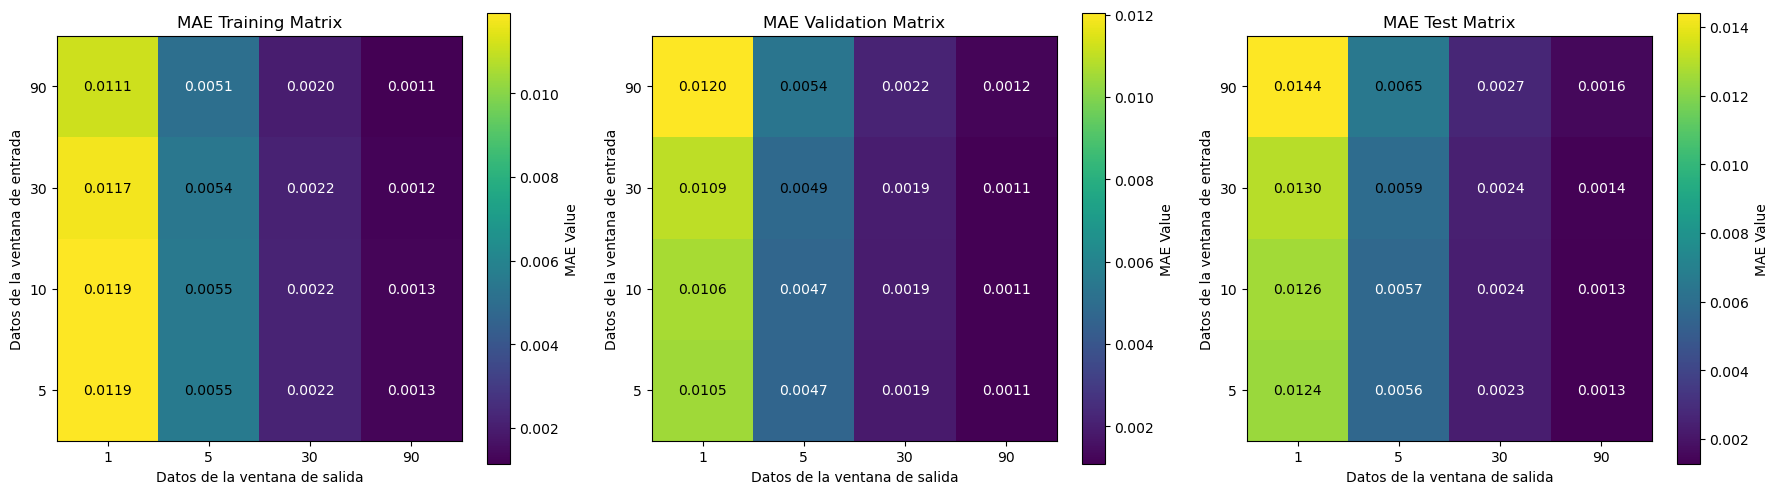

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

matrices = [mae_train_matrix, mae_val_matrix, mae_test_matrix]
titles = ['MAE Training Matrix', 'MAE Validation Matrix', 'MAE Test Matrix']

for i, ax in enumerate(axes):
    im = ax.imshow(matrices[i], cmap='viridis', origin='lower')

    ax.set_xlabel('Datos de la ventana de salida')
    ax.set_ylabel('Datos de la ventana de entrada')
    ax.set_title(titles[i])

    ax.set_xticks(np.arange(len(ventanas_salida)))
    ax.set_xticklabels(ventanas_salida)

    ax.set_yticks(np.arange(len(ventanas_entrada)))
    ax.set_yticklabels(ventanas_entrada)

    for y in range(matrices[i].shape[0]):
        for x in range(matrices[i].shape[1]):
            value = matrices[i][y, x]
            ax.text(x, y, f"{value:.4f}",
                    ha='center', va='center',
                    color='black' if value > np.mean(matrices[i]) else 'white')

    fig.colorbar(im, ax=ax, label='MAE Value')

plt.tight_layout()
plt.show()

## 3. Entrenamiento de modelos de Deep Learning

In [12]:
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.layers import LSTM, GRU
from tensorflow.keras.layers import MaxPooling1D, Convolution1D, GlobalAveragePooling1D
from tensorflow.keras.layers import Dropout, Activation, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from keras import regularizers

### 3.3 Modelos de capas convolucionales (CNN)

#### 3.3.1 Modelos con 5 datos de entrada

##### 3.3.1.1. Modelo con 1 dato de salida

In [15]:
train_data_5_1, train_target_5_1 = dicc_data_train_norm[(5,1)], dicc_target_train_norm[(5,1)]
val_data_5_1, val_target_5_1 = dicc_data_val_norm[(5,1)], dicc_target_val_norm[(5,1)]
test_data_5_1, test_target_5_1 = dicc_data_test_norm[(5,1)], dicc_target_test_norm[(5,1)]

In [25]:
model_CNN_5_1 = Sequential()

# 1. Capa Convolucional
model_CNN_5_1.add(Convolution1D(filters=16, kernel_size=3, activation="relu", padding='same', input_shape=(train_data_5_1.shape[1], train_data_5_1.shape[2])))

# 2. Aplanamos la secuencia
model_CNN_5_1.add(Flatten())
model_CNN_5_1.add(Dropout(0.2))

# 3. Capa Densa de Salida
model_CNN_5_1.add(Dense(train_target_5_1.shape[1], activation='linear'))

# 4. COMPILACIÓN (BAJAMOS el learning rate a 0.0001)
model_CNN_5_1.compile(loss='mean_absolute_error', optimizer=Adam(learning_rate=0.001))

In [26]:
# NO escalamos y porque son retornos (valores pequeños) que el modelo debe aprender directamente
# Usar datos escalados de entrada pero targets sin escalar adicional
hist_CNN_5_1 = model_CNN_5_1.fit(train_data_5_1, train_target_5_1, validation_data=(val_data_5_1, val_target_5_1), epochs=300)

Epoch 1/300
342/342 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.7921 - val_loss: 0.6252
Epoch 2/300
342/342 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.7116 - val_loss: 0.6162
Epoch 3/300
342/342 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.7024 - val_loss: 0.6146
Epoch 4/300
342/342 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.6999 - val_loss: 0.6143
Epoch 5/300
342/342 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.6988 - val_loss: 0.6140
Epoch 6/300
342/342 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.6982 - val_loss: 0.6142
Epoch 7/300
342/342 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.6975 - val_loss: 0.6142
Epoch 8/300
342/342 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.6968 - val_loss: 0.6143
Epoch 9/300
342/342 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.6962 - val_loss: 0.6148
Epoch 10/300
342/342 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.6957 - val_loss: 0.6156
Epoch 11/300
342/342 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.6951 - val_loss: 0.6153
Epoch 12/300
342/342 ━━━━━━━━━━━━━━━━━━━━

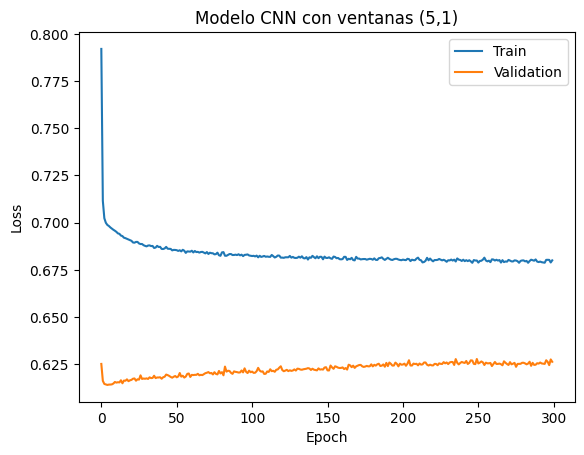

In [27]:
plt.plot(hist_CNN_5_1.history['loss'])
plt.plot(hist_CNN_5_1.history['val_loss'])
#plt.axhline(0.0055)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'])
plt.title('Modelo CNN con ventanas (5,1)')
plt.show()

In [28]:
# 1. El modelo predice en escala normalizada usando los datos de test
y_pred_cnn_scaled_train_5_1 = model_CNN_5_1.predict(train_data_5_1)
y_pred_cnn_scaled_val_5_1 = model_CNN_5_1.predict(val_data_5_1)
y_pred_cnn_scaled_test_5_1 = model_CNN_5_1.predict(test_data_5_1)

# 2. Deshacemos la normalización usando el scaler de la llave (10,5)
scaler_y_5_1 = dicc_scaler[(5,1)]
y_pred_cnn_real_train_5_1 = scaler_y_5_1.inverse_transform(y_pred_cnn_scaled_train_5_1)
y_pred_cnn_real_val_5_1 = scaler_y_5_1.inverse_transform(y_pred_cnn_scaled_val_5_1)
y_pred_cnn_real_test_5_1 = scaler_y_5_1.inverse_transform(y_pred_cnn_scaled_test_5_1)

# 3. Comparamos las predicciones reales contra los datos originales sin normalizar
mae_cnn_train_5_1 = mean_absolute_error(dicc_target_train_reg[(5,1)], y_pred_cnn_real_train_5_1)
mae_cnn_val_5_1 = mean_absolute_error(dicc_target_val[(5,1)], y_pred_cnn_real_val_5_1)
mae_cnn_test_5_1 = mean_absolute_error(dicc_target_test[(5,1)], y_pred_cnn_real_test_5_1)

# 4. Comparamos manzanas con manzanas
print()
print('=======   Resultados modelo CNN (5,1)   =======')
print()
print(f"MAE de la Regresión Lineal (train): {mae_reg_train[(5,1)]:.6f}")
print(f"MAE de la Red Neuronal (train):     {mae_cnn_train_5_1:.6f}")
print()
print(f"MAE de la Regresión Lineal (val): {mae_reg_val[(5,1)]:.6f}")
print(f"MAE de la Red Neuronal (val):     {mae_cnn_val_5_1:.6f}")
print()
print(f"MAE de la Regresión Lineal (test): {mae_reg_test[(5,1)]:.6f}")
print(f"MAE de la Red Neuronal (test):     {mae_cnn_test_5_1:.6f}")
print()

342/342 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
114/114 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

=======   Resultados modelo CNN (5,1)   =======

MAE de la Regresión Lineal (train): 0.011929
MAE de la Red Neuronal (train):     0.011486

MAE de la Regresión Lineal (val): 0.010497
MAE de la Red Neuronal (val):     0.010584

MAE de la Regresión Lineal (test): 0.012439
MAE de la Red Neuronal (test):     0.012722



##### 3.3.1.2. Modelo con 5 datos de salida

In [30]:
train_data_5_5, train_target_5_5 = dicc_data_train_norm[(5,5)], dicc_target_train_norm[(5,5)]
val_data_5_5, val_target_5_5 = dicc_data_val_norm[(5,5)], dicc_target_val_norm[(5,5)]
test_data_5_5, test_target_5_5 = dicc_data_test_norm[(5,5)], dicc_target_test_norm[(5,5)]

In [31]:
model_CNN_5_5 = Sequential()

# 1. Capa Convolucional
model_CNN_5_5.add(Convolution1D(filters=16, kernel_size=3, activation="relu", padding='same', input_shape=(train_data_5_5.shape[1], train_data_5_5.shape[2])))

# 2. Aplanamos la secuencia
model_CNN_5_5.add(Flatten())
#model_CNN_5_5.add(Dropout(0.2))

# 3. Capa Densa de Salida
model_CNN_5_5.add(Dense(train_target_5_5.shape[1], activation='linear'))

# 4. COMPILACIÓN (BAJAMOS el learning rate a 0.0001)
model_CNN_5_5.compile(loss='mean_absolute_error', optimizer=Adam(learning_rate=0.001))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [32]:
# NO escalamos y porque son retornos (valores pequeños) que el modelo debe aprender directamente
# Usar datos escalados de entrada pero targets sin escalar adicional
hist_CNN_5_5 = model_CNN_5_5.fit(train_data_5_5, train_target_5_5, validation_data=(val_data_5_5, val_target_5_5), epochs=300)

Epoch 1/300
342/342 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.7862 - val_loss: 0.6232
Epoch 2/300
342/342 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.7339 - val_loss: 0.6148
Epoch 3/300
342/342 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.7265 - val_loss: 0.6134
Epoch 4/300
342/342 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.7235 - val_loss: 0.6131
Epoch 5/300
342/342 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.7213 - val_loss: 0.6137
Epoch 6/300
342/342 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.7188 - val_loss: 0.6144
Epoch 7/300
342/342 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.7159 - val_loss: 0.6171
Epoch 8/300
342/342 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.7130 - val_loss: 0.6153
Epoch 9/300
342/342 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.7100 - val_loss: 0.6176
Epoch 10/300
342/342 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.7065 - val_loss: 0.6224
Epoch 11/300
342/342 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.7045 - val_loss: 0.6196
Epoch 12/300
342/342 ━━━━━━━━━━━━━━━━━━━━

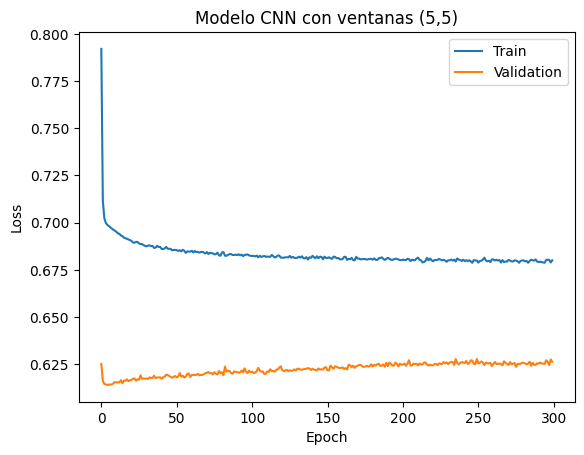

In [33]:
plt.plot(hist_CNN_5_1.history['loss'])
plt.plot(hist_CNN_5_1.history['val_loss'])
#plt.axhline(0.0055)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'])
plt.title('Modelo CNN con ventanas (5,5)')
plt.show()

In [34]:
# 1. El modelo predice en escala normalizada usando los datos de test
y_pred_cnn_scaled_train_5_5 = model_CNN_5_5.predict(train_data_5_5)
y_pred_cnn_scaled_val_5_5 = model_CNN_5_5.predict(val_data_5_5)
y_pred_cnn_scaled_test_5_5 = model_CNN_5_5.predict(test_data_5_5)

# 2. Deshacemos la normalización usando el scaler de la llave (10,5)
scaler_y_5_5 = dicc_scaler[(5,5)]
y_pred_cnn_real_train_5_5 = scaler_y_5_5.inverse_transform(y_pred_cnn_scaled_train_5_5)
y_pred_cnn_real_val_5_5 = scaler_y_5_5.inverse_transform(y_pred_cnn_scaled_val_5_5)
y_pred_cnn_real_test_5_5 = scaler_y_5_5.inverse_transform(y_pred_cnn_scaled_test_5_5)

# 3. Comparamos las predicciones reales contra los datos originales sin normalizar
mae_cnn_train_5_5 = mean_absolute_error(dicc_target_train_reg[(5,5)], y_pred_cnn_real_train_5_5)
mae_cnn_val_5_5 = mean_absolute_error(dicc_target_val[(5,5)], y_pred_cnn_real_val_5_5)
mae_cnn_test_5_5 = mean_absolute_error(dicc_target_test[(5,5)], y_pred_cnn_real_test_5_5)

# 4. Comparamos manzanas con manzanas
print()
print('=======   Resultados modelo CNN (5,5)   =======')
print()
print(f"MAE de la Regresión Lineal (train): {mae_reg_train[(5,5)]:.6f}")
print(f"MAE de la Red Neuronal (train):     {mae_cnn_train_5_5:.6f}")
print()
print(f"MAE de la Regresión Lineal (val): {mae_reg_val[(5,5)]:.6f}")
print(f"MAE de la Red Neuronal (val):     {mae_cnn_val_5_5:.6f}")
print()
print(f"MAE de la Regresión Lineal (test): {mae_reg_test[(5,5)]:.6f}")
print(f"MAE de la Red Neuronal (test):     {mae_cnn_test_5_5:.6f}")
print()

342/342 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
114/114 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

=======   Resultados modelo CNN (5,5)   =======

MAE de la Regresión Lineal (train): 0.005537
MAE de la Red Neuronal (train):     0.005099

MAE de la Regresión Lineal (val): 0.004675
MAE de la Red Neuronal (val):     0.004900

MAE de la Regresión Lineal (test): 0.005641
MAE de la Red Neuronal (test):     0.006022



##### 3.3.1.3. Modelo con 30 datos de salida

In [35]:
train_data_5_30, train_target_5_30 = dicc_data_train_norm[(5,30)], dicc_target_train_norm[(5,30)]
val_data_5_30, val_target_5_30 = dicc_data_val_norm[(5,30)], dicc_target_val_norm[(5,30)]
test_data_5_30, test_target_5_30 = dicc_data_test_norm[(5,30)], dicc_target_test_norm[(5,30)]

In [36]:
model_CNN_5_30 = Sequential()

# 1. Capa Convolucional
model_CNN_5_30.add(Convolution1D(filters=16, kernel_size=3, activation="relu", padding='same', input_shape=(train_data_5_30.shape[1], train_data_5_30.shape[2])))

# 2. Aplanamos la secuencia
model_CNN_5_30.add(Flatten())
#model_CNN_5_30.add(Dropout(0.2))

# 3. Capa Densa de Salida
model_CNN_5_30.add(Dense(train_target_5_30.shape[1], activation='linear'))

# 4. COMPILACIÓN (BAJAMOS el learning rate a 0.0001)
model_CNN_5_30.compile(loss='mean_absolute_error', optimizer=Adam(learning_rate=0.001))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [37]:
# NO escalamos y porque son retornos (valores pequeños) que el modelo debe aprender directamente
# Usar datos escalados de entrada pero targets sin escalar adicional
hist_CNN_5_30 = model_CNN_5_30.fit(train_data_5_30, train_target_5_30, validation_data=(val_data_5_30, val_target_5_30), epochs=300)

Epoch 1/300
341/341 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.8143 - val_loss: 0.6607
Epoch 2/300
341/341 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.7615 - val_loss: 0.6517
Epoch 3/300
341/341 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.7528 - val_loss: 0.6506
Epoch 4/300
341/341 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.7484 - val_loss: 0.6500
Epoch 5/300
341/341 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.7449 - val_loss: 0.6513
Epoch 6/300
341/341 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.7417 - val_loss: 0.6512
Epoch 7/300
341/341 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.7382 - val_loss: 0.6537
Epoch 8/300
341/341 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.7349 - val_loss: 0.6531
Epoch 9/300
341/341 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.7313 - val_loss: 0.6562
Epoch 10/300
341/341 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.7281 - val_loss: 0.6565
Epoch 11/300
341/341 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.7247 - val_loss: 0.6627
Epoch 12/300
341/341 ━━━━━━━━━━━━━━━━━━━━

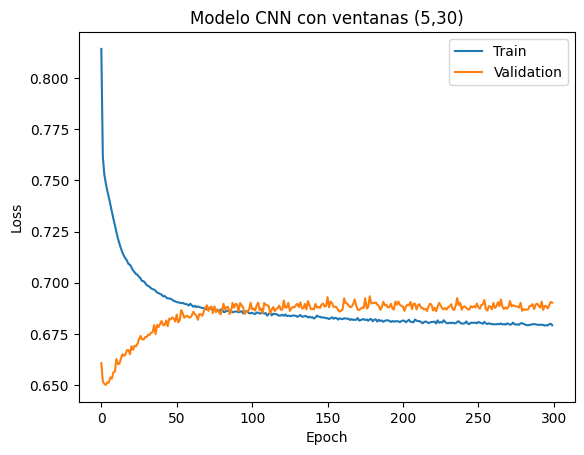

In [38]:
plt.plot(hist_CNN_5_30.history['loss'])
plt.plot(hist_CNN_5_30.history['val_loss'])
#plt.axhline(0.0055)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'])
plt.title('Modelo CNN con ventanas (5,30)')
plt.show()

In [39]:
# 1. El modelo predice en escala normalizada usando los datos de test
y_pred_cnn_scaled_train_5_30 = model_CNN_5_30.predict(train_data_5_30)
y_pred_cnn_scaled_val_5_30 = model_CNN_5_30.predict(val_data_5_30)
y_pred_cnn_scaled_test_5_30 = model_CNN_5_30.predict(test_data_5_30)

# 2. Deshacemos la normalización usando el scaler de la llave (10,5)
scaler_y_5_30 = dicc_scaler[(5,30)]
y_pred_cnn_real_train_5_30 = scaler_y_5_30.inverse_transform(y_pred_cnn_scaled_train_5_30)
y_pred_cnn_real_val_5_30 = scaler_y_5_30.inverse_transform(y_pred_cnn_scaled_val_5_30)
y_pred_cnn_real_test_5_30 = scaler_y_5_30.inverse_transform(y_pred_cnn_scaled_test_5_30)

# 3. Comparamos las predicciones reales contra los datos originales sin normalizar
mae_cnn_train_5_30 = mean_absolute_error(dicc_target_train_reg[(5,30)], y_pred_cnn_real_train_5_30)
mae_cnn_val_5_30 = mean_absolute_error(dicc_target_val[(5,30)], y_pred_cnn_real_val_5_30)
mae_cnn_test_5_30 = mean_absolute_error(dicc_target_test[(5,30)], y_pred_cnn_real_test_5_30)

# 4. Comparamos manzanas con manzanas
print()
print('=======   Resultados modelo CNN (5,5)   =======')
print()
print(f"MAE de la Regresión Lineal (train): {mae_reg_train[(5,30)]:.6f}")
print(f"MAE de la Red Neuronal (train):     {mae_cnn_train_5_30:.6f}")
print()
print(f"MAE de la Regresión Lineal (val): {mae_reg_val[(5,30)]:.6f}")
print(f"MAE de la Red Neuronal (val):     {mae_cnn_val_5_30:.6f}")
print()
print(f"MAE de la Regresión Lineal (test): {mae_reg_test[(5,30)]:.6f}")
print(f"MAE de la Red Neuronal (test):     {mae_cnn_test_5_30:.6f}")
print()

341/341 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
114/114 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

=======   Resultados modelo CNN (5,5)   =======

MAE de la Regresión Lineal (train): 0.002226
MAE de la Red Neuronal (train):     0.002008

MAE de la Regresión Lineal (val): 0.001901
MAE de la Red Neuronal (val):     0.002022

MAE de la Regresión Lineal (test): 0.002342
MAE de la Red Neuronal (test):     0.002597



##### 3.3.1.4. Modelo con 90 datos de salida

In [40]:
train_data_5_90, train_target_5_90 = dicc_data_train_norm[(5,90)], dicc_target_train_norm[(5,90)]
val_data_5_90, val_target_5_90 = dicc_data_val_norm[(5,90)], dicc_target_val_norm[(5,90)]
test_data_5_90, test_target_5_90 = dicc_data_test_norm[(5,90)], dicc_target_test_norm[(5,90)]

In [51]:
model_CNN_5_90 = Sequential()

# 1. Capa Convolucional
model_CNN_5_90.add(Convolution1D(filters=16, kernel_size=3, activation="relu", padding='same', input_shape=(train_data_5_90.shape[1], train_data_5_90.shape[2])))

# 2. Aplanamos la secuencia
model_CNN_5_90.add(Flatten())
model_CNN_5_90.add(Dropout(0.2))

# 3. Capa Densa de Salida
model_CNN_5_90.add(Dense(train_target_5_90.shape[1], activation='linear'))

# 4. COMPILACIÓN (BAJAMOS el learning rate a 0.0001)
model_CNN_5_90.compile(loss='mean_absolute_error', optimizer=Adam(learning_rate=0.001))

In [52]:
# NO escalamos y porque son retornos (valores pequeños) que el modelo debe aprender directamente
# Usar datos escalados de entrada pero targets sin escalar adicional
hist_CNN_5_90 = model_CNN_5_90.fit(train_data_5_90, train_target_5_90, validation_data=(val_data_5_90, val_target_5_90), epochs=200)

Epoch 1/200
340/340 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.8402 - val_loss: 0.6713
Epoch 2/200
340/340 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.7716 - val_loss: 0.6651
Epoch 3/200
340/340 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.7617 - val_loss: 0.6635
Epoch 4/200
340/340 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.7577 - val_loss: 0.6662
Epoch 5/200
340/340 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.7532 - val_loss: 0.6680
Epoch 6/200
340/340 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.7492 - val_loss: 0.6694
Epoch 7/200
340/340 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.7443 - val_loss: 0.6708
Epoch 8/200
340/340 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.7410 - val_loss: 0.6694
Epoch 9/200
340/340 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.7374 - val_loss: 0.6724
Epoch 10/200
340/340 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.7357 - val_loss: 0.6699
Epoch 11/200
340/340 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.7330 - val_loss: 0.6721
Epoch 12/200
340/340 ━━━━━━━━━━━━━━━━━━━━

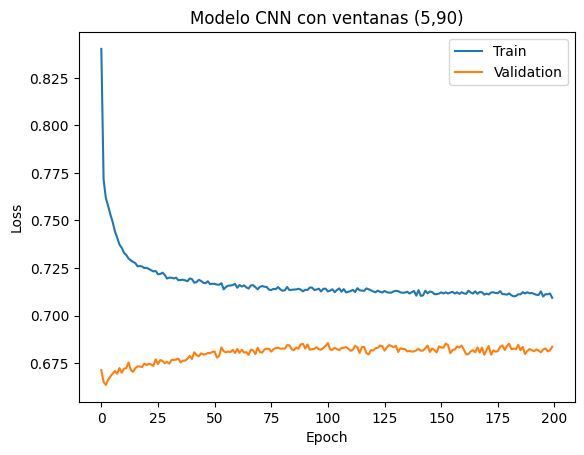

In [53]:
plt.plot(hist_CNN_5_90.history['loss'])
plt.plot(hist_CNN_5_90.history['val_loss'])
#plt.axhline(0.0055)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'])
plt.title('Modelo CNN con ventanas (5,90)')
plt.show()

In [54]:
# 1. El modelo predice en escala normalizada usando los datos de test
y_pred_cnn_scaled_train_5_90 = model_CNN_5_90.predict(train_data_5_90)
y_pred_cnn_scaled_val_5_90 = model_CNN_5_90.predict(val_data_5_90)
y_pred_cnn_scaled_test_5_90 = model_CNN_5_90.predict(test_data_5_90)

# 2. Deshacemos la normalización usando el scaler de la llave (10,5)
scaler_y_5_90 = dicc_scaler[(5,90)]
y_pred_cnn_real_train_5_90 = scaler_y_5_90.inverse_transform(y_pred_cnn_scaled_train_5_90)
y_pred_cnn_real_val_5_90 = scaler_y_5_90.inverse_transform(y_pred_cnn_scaled_val_5_90)
y_pred_cnn_real_test_5_90 = scaler_y_5_90.inverse_transform(y_pred_cnn_scaled_test_5_90)

# 3. Comparamos las predicciones reales contra los datos originales sin normalizar
mae_cnn_train_5_90 = mean_absolute_error(dicc_target_train_reg[(5,90)], y_pred_cnn_real_train_5_90)
mae_cnn_val_5_90 = mean_absolute_error(dicc_target_val[(5,90)], y_pred_cnn_real_val_5_90)
mae_cnn_test_5_90 = mean_absolute_error(dicc_target_test[(5,90)], y_pred_cnn_real_test_5_90)

# 4. Comparamos manzanas con manzanas
print()
print('=======   Resultados modelo CNN (5,90)   =======')
print()
print(f"MAE de la Regresión Lineal (train): {mae_reg_train[(5,90)]:.6f}")
print(f"MAE de la Red Neuronal (train):     {mae_cnn_train_5_90:.6f}")
print()
print(f"MAE de la Regresión Lineal (val): {mae_reg_val[(5,90)]:.6f}")
print(f"MAE de la Red Neuronal (val):     {mae_cnn_val_5_90:.6f}")
print()
print(f"MAE de la Regresión Lineal (test): {mae_reg_test[(5,90)]:.6f}")
print(f"MAE de la Red Neuronal (test):     {mae_cnn_test_5_90:.6f}")
print()

340/340 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
114/114 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step

=======   Resultados modelo CNN (5,90)   =======

MAE de la Regresión Lineal (train): 0.001277
MAE de la Red Neuronal (train):     0.001167

MAE de la Regresión Lineal (val): 0.001090
MAE de la Red Neuronal (val):     0.001122

MAE de la Regresión Lineal (test): 0.001275
MAE de la Red Neuronal (test):     0.001378



#### 3.3.2 Modelos con 10 datos de entrada

##### 3.3.2.1. Modelo con 1 dato de salida

In [55]:
train_data_10_1, train_target_10_1 = dicc_data_train_norm[(10,1)], dicc_target_train_norm[(10,1)]
val_data_10_1, val_target_10_1 = dicc_data_val_norm[(10,1)], dicc_target_val_norm[(10,1)]
test_data_10_1, test_target_10_1 = dicc_data_test_norm[(10,1)], dicc_target_test_norm[(10,1)]

In [61]:
model_CNN_10_1 = Sequential()

# 1. Capa Convolucional
model_CNN_10_1.add(Convolution1D(filters=32, kernel_size=3, activation="relu", padding='same', input_shape=(train_data_10_1.shape[1], train_data_10_1.shape[2])))

# 2. Aplanamos la secuencia
model_CNN_10_1.add(Flatten())
model_CNN_10_1.add(Dropout(0.3))

# 3. Capa Densa de Salida
model_CNN_10_1.add(Dense(train_target_10_1.shape[1], activation='linear'))

# 4. COMPILACIÓN (BAJAMOS el learning rate a 0.0001)
model_CNN_10_1.compile(loss='mean_absolute_error', optimizer=Adam(learning_rate=0.001))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [62]:
# NO escalamos y porque son retornos (valores pequeños) que el modelo debe aprender directamente
# Usar datos escalados de entrada pero targets sin escalar adicional
hist_CNN_10_1 = model_CNN_10_1.fit(train_data_10_1, train_target_10_1, validation_data=(val_data_10_1, val_target_10_1), epochs=300)

Epoch 1/300
342/342 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 0.7904 - val_loss: 0.6220
Epoch 2/300
342/342 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.7122 - val_loss: 0.6156
Epoch 3/300
342/342 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 0.7017 - val_loss: 0.6149
Epoch 4/300
342/342 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.6984 - val_loss: 0.6151
Epoch 5/300
342/342 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.6964 - val_loss: 0.6159
Epoch 6/300
342/342 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.6952 - val_loss: 0.6165
Epoch 7/300
342/342 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.6937 - val_loss: 0.6170
Epoch 8/300
342/342 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.6922 - val_loss: 0.6174
Epoch 9/300
342/342 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.6911 - val_loss: 0.6185
Epoch 10/300
342/342 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.6901 - val_loss: 0.6184
Epoch 11/300
342/342 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.6891 - val_loss: 0.6193
Epoch 12/300
342/342 ━━━━━━━━━━━━━━━━━━━━

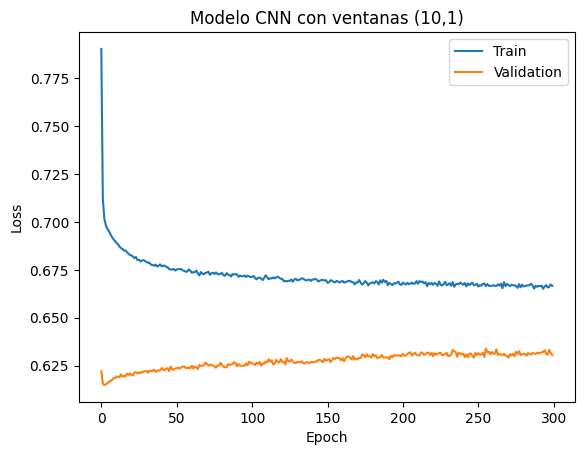

In [63]:
plt.plot(hist_CNN_10_1.history['loss'])
plt.plot(hist_CNN_10_1.history['val_loss'])
#plt.axhline(0.0055)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation', 'Regresión Lineal'])
plt.title('Modelo CNN con ventanas (10,1)')
plt.show()

In [64]:
# 1. El modelo predice en escala normalizada usando los datos de test
y_pred_cnn_scaled_train_10_1 = model_CNN_10_1.predict(train_data_10_1)
y_pred_cnn_scaled_val_10_1 = model_CNN_10_1.predict(val_data_10_1)
y_pred_cnn_scaled_test_10_1 = model_CNN_10_1.predict(test_data_10_1)

# 2. Deshacemos la normalización usando el scaler de la llave (10,5)
scaler_y_10_1 = dicc_scaler[(10,1)]
y_pred_cnn_real_train_10_1 = scaler_y_10_1.inverse_transform(y_pred_cnn_scaled_train_10_1)
y_pred_cnn_real_val_10_1 = scaler_y_10_1.inverse_transform(y_pred_cnn_scaled_val_10_1)
y_pred_cnn_real_test_10_1 = scaler_y_10_1.inverse_transform(y_pred_cnn_scaled_test_10_1)

# 3. Comparamos las predicciones reales contra los datos originales sin normalizar
mae_cnn_train_10_1 = mean_absolute_error(dicc_target_train_reg[(10,1)], y_pred_cnn_real_train_10_1)
mae_cnn_val_10_1 = mean_absolute_error(dicc_target_val[(10,1)], y_pred_cnn_real_val_10_1)
mae_cnn_test_10_1 = mean_absolute_error(dicc_target_test[(10,1)], y_pred_cnn_real_test_10_1)

# 4. Comparamos manzanas con manzanas
print()
print('=======   Resultados modelo CNN (10,1)   =======')
print()
print(f"MAE de la Regresión Lineal (train): {mae_reg_train[(10,1)]:.6f}")
print(f"MAE de la Red Neuronal (train):     {mae_cnn_train_10_1:.6f}")
print()
print(f"MAE de la Regresión Lineal (val): {mae_reg_val[(10,1)]:.6f}")
print(f"MAE de la Red Neuronal (val):     {mae_cnn_val_10_1:.6f}")
print()
print(f"MAE de la Regresión Lineal (test): {mae_reg_test[(10,1)]:.6f}")
print(f"MAE de la Red Neuronal (test):     {mae_cnn_test_10_1:.6f}")
print()

342/342 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
114/114 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

=======   Resultados modelo CNN (10,1)   =======

MAE de la Regresión Lineal (train): 0.011893
MAE de la Red Neuronal (train):     0.011130

MAE de la Regresión Lineal (val): 0.010598
MAE de la Red Neuronal (val):     0.010649

MAE de la Regresión Lineal (test): 0.012597
MAE de la Red Neuronal (test):     0.012902



##### 3.3.2.2. Modelo con 5 datos de salida

In [65]:
train_data_10_5, train_target_10_5 = dicc_data_train_norm[(10,5)], dicc_target_train_norm[(10,5)]
val_data_10_5, val_target_10_5 = dicc_data_val_norm[(10,5)], dicc_target_val_norm[(10,5)]
test_data_10_5, test_target_10_5 = dicc_data_test_norm[(10,5)], dicc_target_test_norm[(10,5)]

In [79]:
model_CNN_10_5 = Sequential()

# 1. Capa Convolucional
model_CNN_10_5.add(Convolution1D(filters=32, kernel_size=3, activation="relu", padding='same', input_shape=(train_data_10_5.shape[1], train_data_10_5.shape[2])))
model_CNN_10_5.add(Convolution1D(filters=16, kernel_size=3, activation="relu", padding='same'))

# 2. Aplanamos la secuencia
model_CNN_10_5.add(Flatten())
model_CNN_10_5.add(Dropout(0.3))

# 3. Capa Densa de Salida
model_CNN_10_5.add(Dense(train_target_10_5.shape[1], activation='linear'))

# 4. COMPILACIÓN (BAJAMOS el learning rate a 0.0001)
model_CNN_10_5.compile(loss='mean_absolute_error', optimizer=Adam(learning_rate=0.001))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [85]:
# NO escalamos y porque son retornos (valores pequeños) que el modelo debe aprender directamente
# Usar datos escalados de entrada pero targets sin escalar adicional
hist_CNN_10_5 = model_CNN_10_5.fit(train_data_10_5, train_target_10_5, validation_data=(val_data_10_5, val_target_10_5), epochs=200)

Epoch 1/200
342/342 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.6439 - val_loss: 0.6372
Epoch 2/200
342/342 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.6424 - val_loss: 0.6386
Epoch 3/200
342/342 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.6431 - val_loss: 0.6388
Epoch 4/200
342/342 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.6436 - val_loss: 0.6382
Epoch 5/200
342/342 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.6445 - val_loss: 0.6375
Epoch 6/200
342/342 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.6451 - val_loss: 0.6364
Epoch 7/200
342/342 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.6438 - val_loss: 0.6368
Epoch 8/200
342/342 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.6440 - val_loss: 0.6386
Epoch 9/200
342/342 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.6429 - val_loss: 0.6397
Epoch 10/200
342/342 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.6419 - val_loss: 0.6379
Epoch 11/200
342/342 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.6437 - val_loss: 0.6373
Epoch 12/200
342/342 ━━━━━━━━━━━━━━━━━━━━

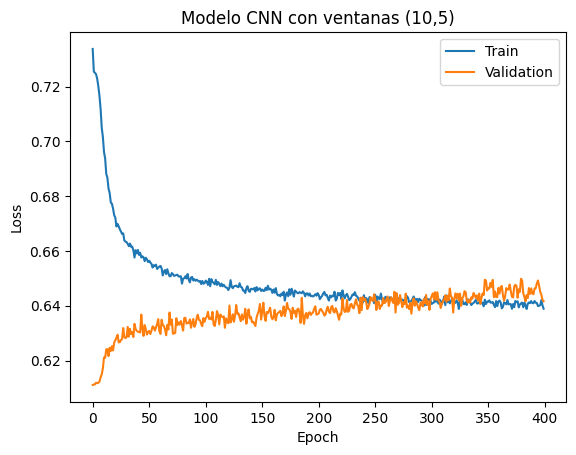

In [87]:
plt.plot(hist_CNN_10_5.history['loss'])
plt.plot(hist_CNN_10_5.history['val_loss'])
#plt.axhline(0.0055)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation', 'Regresión Lineal'])
plt.title('Modelo CNN con ventanas (10,5)')
plt.show()

In [88]:
# 1. El modelo predice en escala normalizada usando los datos de test
y_pred_cnn_scaled_train_10_5 = model_CNN_10_5.predict(train_data_10_5)
y_pred_cnn_scaled_val_10_5 = model_CNN_10_5.predict(val_data_10_5)
y_pred_cnn_scaled_test_10_5 = model_CNN_10_5.predict(test_data_10_5)

# 2. Deshacemos la normalización usando el scaler de la llave (10,5)
scaler_y_10_5 = dicc_scaler[(10,5)]
y_pred_cnn_real_train_10_5 = scaler_y_10_5.inverse_transform(y_pred_cnn_scaled_train_10_5)
y_pred_cnn_real_val_10_5 = scaler_y_10_5.inverse_transform(y_pred_cnn_scaled_val_10_5)
y_pred_cnn_real_test_10_5 = scaler_y_10_5.inverse_transform(y_pred_cnn_scaled_test_10_5)

# 3. Comparamos las predicciones reales contra los datos originales sin normalizar
mae_cnn_train_10_5 = mean_absolute_error(dicc_target_train_reg[(10,5)], y_pred_cnn_real_train_10_5)
mae_cnn_val_10_5 = mean_absolute_error(dicc_target_val[(10,5)], y_pred_cnn_real_val_10_5)
mae_cnn_test_10_5 = mean_absolute_error(dicc_target_test[(10,5)], y_pred_cnn_real_test_10_5)

# 4. Comparamos manzanas con manzanas
print()
print('=======   Resultados modelo CNN (10,5)   =======')
print()
print(f"MAE de la Regresión Lineal (train): {mae_reg_train[(10,5)]:.6f}")
print(f"MAE de la Red Neuronal (train):     {mae_cnn_train_10_5:.6f}")
print()
print(f"MAE de la Regresión Lineal (val): {mae_reg_val[(10,5)]:.6f}")
print(f"MAE de la Red Neuronal (val):     {mae_cnn_val_10_5:.6f}")
print()
print(f"MAE de la Regresión Lineal (test): {mae_reg_test[(10,5)]:.6f}")
print(f"MAE de la Red Neuronal (test):     {mae_cnn_test_10_5:.6f}")
print()

342/342 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
114/114 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

=======   Resultados modelo CNN (10,5)   =======

MAE de la Regresión Lineal (train): 0.005508
MAE de la Red Neuronal (train):     0.004743

MAE de la Regresión Lineal (val): 0.004713
MAE de la Red Neuronal (val):     0.004870

MAE de la Regresión Lineal (test): 0.005716
MAE de la Red Neuronal (test):     0.005939



##### 3.3.2.3. Modelo con 30 datos de salida

In [13]:
train_data_10_30, train_target_10_30 = dicc_data_train_norm[(10,30)], dicc_target_train_norm[(10,30)]
val_data_10_30, val_target_10_30 = dicc_data_val_norm[(10,30)], dicc_target_val_norm[(10,30)]
test_data_10_30, test_target_10_30 = dicc_data_test_norm[(10,30)], dicc_target_test_norm[(10,30)]

In [34]:
model_CNN_10_30 = Sequential()

# 1. Capa Convolucional
model_CNN_10_30.add(Convolution1D(filters=32, kernel_size=3, activation="relu", padding='same', input_shape=(train_data_10_30.shape[1], train_data_10_30.shape[2])))
model_CNN_10_30.add(Convolution1D(filters=32, kernel_size=3, activation="relu", padding='same'))

# 2. Aplanamos la secuencia
model_CNN_10_30.add(Flatten())
model_CNN_10_30.add(Dropout(0.5))

# 3. Capa Densa de Salida
model_CNN_10_30.add(Dense(train_target_10_30.shape[1], activation='linear'))

# 4. COMPILACIÓN (BAJAMOS el learning rate a 0.0001)
model_CNN_10_30.compile(loss='mean_absolute_error', optimizer=Adam(learning_rate=0.001))

c:\Users\mateo\anaconda31\envs\trading\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [35]:
# NO escalamos y porque son retornos (valores pequeños) que el modelo debe aprender directamente
# Usar datos escalados de entrada pero targets sin escalar adicional
hist_CNN_10_30 = model_CNN_10_30.fit(train_data_10_30, train_target_10_30, validation_data=(val_data_10_30, val_target_10_30), epochs=150)

Epoch 1/150
341/341 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 0.7631 - val_loss: 0.6461
Epoch 2/150
341/341 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.7528 - val_loss: 0.6463
Epoch 3/150
341/341 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.7522 - val_loss: 0.6463
Epoch 4/150
341/341 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.7499 - val_loss: 0.6464
Epoch 5/150
341/341 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.7391 - val_loss: 0.6478
Epoch 6/150
341/341 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.7235 - val_loss: 0.6519
Epoch 7/150
341/341 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.7068 - val_loss: 0.6565
Epoch 8/150
341/341 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.6943 - val_loss: 0.6583
Epoch 9/150
341/341 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.6843 - val_loss: 0.6627
Epoch 10/150
341/341 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.6755 - val_loss: 0.6605
Epoch 11/150
341/341 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.6684 - val_loss: 0.6633
Epoch 12/150
341/341 ━━━━━━━━━━━━━━━━━━━━

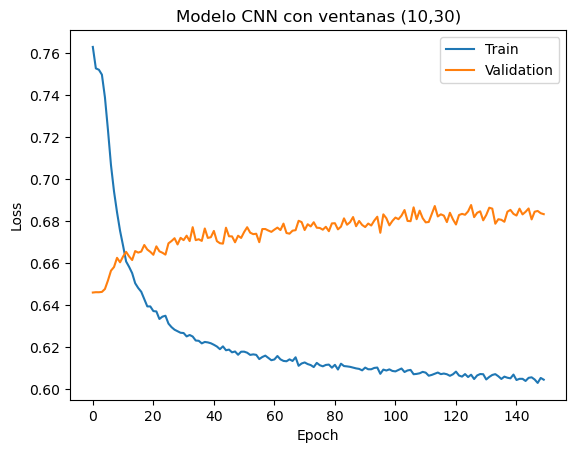

In [36]:
plt.plot(hist_CNN_10_30.history['loss'])
plt.plot(hist_CNN_10_30.history['val_loss'])
#plt.axhline(0.0055)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation', 'Regresión Lineal'])
plt.title('Modelo CNN con ventanas (10,30)')
plt.show()

In [37]:
# 1. El modelo predice en escala normalizada usando los datos de test
y_pred_cnn_scaled_train_10_30 = model_CNN_10_30.predict(train_data_10_30)
y_pred_cnn_scaled_val_10_30 = model_CNN_10_30.predict(val_data_10_30)
y_pred_cnn_scaled_test_10_30 = model_CNN_10_30.predict(test_data_10_30)

# 2. Deshacemos la normalización usando el scaler de la llave (10,5)
scaler_y_10_30 = dicc_scaler[(10,30)]
y_pred_cnn_real_train_10_30 = scaler_y_10_30.inverse_transform(y_pred_cnn_scaled_train_10_30)
y_pred_cnn_real_val_10_30 = scaler_y_10_30.inverse_transform(y_pred_cnn_scaled_val_10_30)
y_pred_cnn_real_test_10_30 = scaler_y_10_30.inverse_transform(y_pred_cnn_scaled_test_10_30)

# 3. Comparamos las predicciones reales contra los datos originales sin normalizar
mae_cnn_train_10_30 = mean_absolute_error(dicc_target_train_reg[(10,30)], y_pred_cnn_real_train_10_30)
mae_cnn_val_10_30 = mean_absolute_error(dicc_target_val[(10,30)], y_pred_cnn_real_val_10_30)
mae_cnn_test_10_30 = mean_absolute_error(dicc_target_test[(10,30)], y_pred_cnn_real_test_10_30)

# 4. Comparamos manzanas con manzanas
print()
print('=======   Resultados modelo CNN (10,30)   =======')
print()
print(f"MAE de la Regresión Lineal (train): {mae_reg_train[(10,30)]:.6f}")
print(f"MAE de la Red Neuronal (train):     {mae_cnn_train_10_30:.6f}")
print()
print(f"MAE de la Regresión Lineal (val): {mae_reg_val[(10,30)]:.6f}")
print(f"MAE de la Red Neuronal (val):     {mae_cnn_val_10_30:.6f}")
print()
print(f"MAE de la Regresión Lineal (test): {mae_reg_test[(10,30)]:.6f}")
print(f"MAE de la Red Neuronal (test):     {mae_cnn_test_10_30:.6f}")
print()

341/341 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
114/114 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step

=======   Resultados modelo CNN (10,30)   =======

MAE de la Regresión Lineal (train): 0.002213
MAE de la Red Neuronal (train):     0.001677

MAE de la Regresión Lineal (val): 0.001908
MAE de la Red Neuronal (val):     0.002002

MAE de la Regresión Lineal (test): 0.002362
MAE de la Red Neuronal (test):     0.002452



##### 3.3.2.4. Modelo con 90 datos de salida

In [18]:
train_data_10_90, train_target_10_90 = dicc_data_train_norm[(10,90)], dicc_target_train_norm[(10,90)]
val_data_10_90, val_target_10_90 = dicc_data_val_norm[(10,90)], dicc_target_val_norm[(10,90)]
test_data_10_90, test_target_10_90 = dicc_data_test_norm[(10,90)], dicc_target_test_norm[(10,90)]

In [30]:
model_CNN_10_90 = Sequential()

# 1. Capa Convolucional
model_CNN_10_90.add(Convolution1D(filters=32, kernel_size=3, activation="relu", padding='same', input_shape=(train_data_10_90.shape[1], train_data_10_90.shape[2])))
model_CNN_10_90.add(Convolution1D(filters=16, kernel_size=3, activation="relu", padding='same'))

# 2. Aplanamos la secuencia
model_CNN_10_90.add(Flatten())
model_CNN_10_90.add(Dropout(0.5))

# 3. Capa Densa de Salida
model_CNN_10_90.add(Dense(train_target_10_90.shape[1], activation='linear'))

# 4. COMPILACIÓN (BAJAMOS el learning rate a 0.0001)
model_CNN_10_90.compile(loss='mean_absolute_error', optimizer=Adam(learning_rate=0.001))

c:\Users\mateo\anaconda31\envs\trading\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [31]:
# NO escalamos y porque son retornos (valores pequeños) que el modelo debe aprender directamente
# Usar datos escalados de entrada pero targets sin escalar adicional
hist_CNN_10_90 = model_CNN_10_90.fit(train_data_10_90, train_target_10_90, validation_data=(val_data_10_90, val_target_10_90), epochs=150)

Epoch 1/150
340/340 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 0.7745 - val_loss: 0.6599
Epoch 2/150
340/340 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.7616 - val_loss: 0.6602
Epoch 3/150
340/340 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 0.7611 - val_loss: 0.6604
Epoch 4/150
340/340 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.7594 - val_loss: 0.6607
Epoch 5/150
340/340 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.7544 - val_loss: 0.6630
Epoch 6/150
340/340 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.7433 - val_loss: 0.6686
Epoch 7/150
340/340 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.7285 - val_loss: 0.6738
Epoch 8/150
340/340 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 0.7159 - val_loss: 0.6764
Epoch 9/150
340/340 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.7071 - val_loss: 0.6815
Epoch 10/150
340/340 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.6990 - val_loss: 0.6786
Epoch 11/150
340/340 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.6922 - val_loss: 0.6843
Epoch 12/150
340/340 ━━━━━━━━━━━━━━━━━━

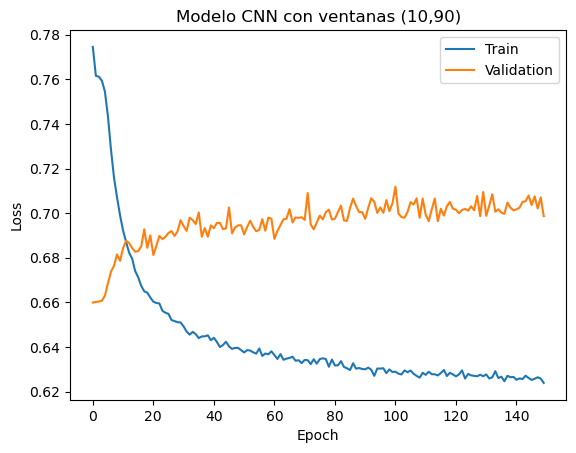

In [32]:
plt.plot(hist_CNN_10_90.history['loss'])
plt.plot(hist_CNN_10_90.history['val_loss'])
#plt.axhline(0.0055)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation', 'Regresión Lineal'])
plt.title('Modelo CNN con ventanas (10,90)')
plt.show()

In [33]:
# 1. El modelo predice en escala normalizada usando los datos de test
y_pred_cnn_scaled_train_10_90 = model_CNN_10_90.predict(train_data_10_90)
y_pred_cnn_scaled_val_10_90 = model_CNN_10_90.predict(val_data_10_90)
y_pred_cnn_scaled_test_10_90 = model_CNN_10_90.predict(test_data_10_90)

# 2. Deshacemos la normalización usando el scaler de la llave (10,5)
scaler_y_10_90 = dicc_scaler[(10,90)]
y_pred_cnn_real_train_10_90 = scaler_y_10_90.inverse_transform(y_pred_cnn_scaled_train_10_90)
y_pred_cnn_real_val_10_90 = scaler_y_10_90.inverse_transform(y_pred_cnn_scaled_val_10_90)
y_pred_cnn_real_test_10_90 = scaler_y_10_90.inverse_transform(y_pred_cnn_scaled_test_10_90)

# 3. Comparamos las predicciones reales contra los datos originales sin normalizar
mae_cnn_train_10_90 = mean_absolute_error(dicc_target_train_reg[(10,90)], y_pred_cnn_real_train_10_90)
mae_cnn_val_10_90 = mean_absolute_error(dicc_target_val[(10,90)], y_pred_cnn_real_val_10_90)
mae_cnn_test_10_90 = mean_absolute_error(dicc_target_test[(10,90)], y_pred_cnn_real_test_10_90)

# 4. Comparamos manzanas con manzanas
print()
print('=======   Resultados modelo CNN (10,90)   =======')
print()
print(f"MAE de la Regresión Lineal (train): {mae_reg_train[(10,90)]:.6f}")
print(f"MAE de la Red Neuronal (train):     {mae_cnn_train_10_90:.6f}")
print()
print(f"MAE de la Regresión Lineal (val): {mae_reg_val[(10,90)]:.6f}")
print(f"MAE de la Red Neuronal (val):     {mae_cnn_val_10_90:.6f}")
print()
print(f"MAE de la Regresión Lineal (test): {mae_reg_test[(10,90)]:.6f}")
print(f"MAE de la Red Neuronal (test):     {mae_cnn_test_10_90:.6f}")
print()

340/340 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
114/114 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step

=======   Resultados modelo CNN (10,90)   =======

MAE de la Regresión Lineal (train): 0.001270
MAE de la Red Neuronal (train):     0.000991

MAE de la Regresión Lineal (val): 0.001100
MAE de la Red Neuronal (val):     0.001145

MAE de la Regresión Lineal (test): 0.001285
MAE de la Red Neuronal (test):     0.001345



#### 3.3.3 Modelos con 30 datos de entrada

##### 3.3.3.1. Modelo con 1 dato de salida

In [23]:
train_data_30_1, train_target_30_1 = dicc_data_train_norm[(30,1)], dicc_target_train_norm[(30,1)]
val_data_30_1, val_target_30_1 = dicc_data_val_norm[(30,1)], dicc_target_val_norm[(30,1)]
test_data_30_1, test_target_30_1 = dicc_data_test_norm[(30,1)], dicc_target_test_norm[(30,1)]

In [38]:
model_CNN_30_1 = Sequential()

# 1. Capa Convolucional
model_CNN_30_1.add(Convolution1D(filters=32, kernel_size=3, activation="relu", padding='same', input_shape=(train_data_30_1.shape[1], train_data_30_1.shape[2])))
model_CNN_30_1.add(Convolution1D(filters=32, kernel_size=3, activation="relu", padding='same'))

# 2. Aplanamos la secuencia
model_CNN_30_1.add(Flatten())
model_CNN_30_1.add(Dropout(0.5))

# 3. Capa Densa de Salida
model_CNN_30_1.add(Dense(train_target_30_1.shape[1], activation='linear'))

# 4. COMPILACIÓN (BAJAMOS el learning rate a 0.0001)
model_CNN_30_1.compile(loss='mean_absolute_error', optimizer=Adam(learning_rate=0.001))

c:\Users\mateo\anaconda31\envs\trading\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [39]:
# NO escalamos y porque son retornos (valores pequeños) que el modelo debe aprender directamente
# Usar datos escalados de entrada pero targets sin escalar adicional
hist_CNN_30_1 = model_CNN_30_1.fit(train_data_30_1, train_target_30_1, validation_data=(val_data_30_1, val_target_30_1), epochs=200)

Epoch 1/200
341/341 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - loss: 0.7086 - val_loss: 0.6137
Epoch 2/200
341/341 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.6988 - val_loss: 0.6136
Epoch 3/200
341/341 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.6986 - val_loss: 0.6136
Epoch 4/200
341/341 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.6984 - val_loss: 0.6137
Epoch 5/200
341/341 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.6980 - val_loss: 0.6136
Epoch 6/200
341/341 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.6973 - val_loss: 0.6136
Epoch 7/200
341/341 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.6961 - val_loss: 0.6137
Epoch 8/200
341/341 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.6949 - val_loss: 0.6136
Epoch 9/200
341/341 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.6924 - val_loss: 0.6140
Epoch 10/200
341/341 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.6899 - val_loss: 0.6143
Epoch 11/200
341/341 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.6880 - val_loss: 0.6144
Epoch 12/200
341/341 ━━━━━━━━━━━━━━━━━━━━

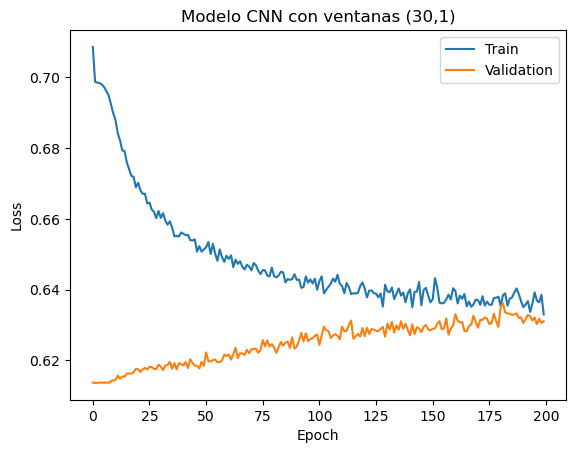

In [40]:
plt.plot(hist_CNN_30_1.history['loss'])
plt.plot(hist_CNN_30_1.history['val_loss'])
#plt.axhline(0.0055)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation', 'Regresión Lineal'])
plt.title('Modelo CNN con ventanas (30,1)')
plt.show()

In [41]:
# 1. El modelo predice en escala normalizada usando los datos de test
y_pred_cnn_scaled_train_30_1 = model_CNN_30_1.predict(train_data_30_1)
y_pred_cnn_scaled_val_30_1 = model_CNN_30_1.predict(val_data_30_1)
y_pred_cnn_scaled_test_30_1 = model_CNN_30_1.predict(test_data_30_1)

# 2. Deshacemos la normalización usando el scaler de la llave (10,5)
scaler_y_30_1 = dicc_scaler[(30,1)]
y_pred_cnn_real_train_30_1 = scaler_y_30_1.inverse_transform(y_pred_cnn_scaled_train_30_1)
y_pred_cnn_real_val_30_1 = scaler_y_30_1.inverse_transform(y_pred_cnn_scaled_val_30_1)
y_pred_cnn_real_test_30_1 = scaler_y_30_1.inverse_transform(y_pred_cnn_scaled_test_30_1)

# 3. Comparamos las predicciones reales contra los datos originales sin normalizar
mae_cnn_train_30_1 = mean_absolute_error(dicc_target_train_reg[(30,1)], y_pred_cnn_real_train_30_1)
mae_cnn_val_30_1 = mean_absolute_error(dicc_target_val[(30,1)], y_pred_cnn_real_val_30_1)
mae_cnn_test_30_1 = mean_absolute_error(dicc_target_test[(30,1)], y_pred_cnn_real_test_30_1)

# 4. Comparamos manzanas con manzanas
print()
print('=======   Resultados modelo CNN (30,1)   =======')
print()
print(f"MAE de la Regresión Lineal (train): {mae_reg_train[(30,1)]:.6f}")
print(f"MAE de la Red Neuronal (train):     {mae_cnn_train_30_1:.6f}")
print()
print(f"MAE de la Regresión Lineal (val): {mae_reg_val[(30,1)]:.6f}")
print(f"MAE de la Red Neuronal (val):     {mae_cnn_val_30_1:.6f}")
print()
print(f"MAE de la Regresión Lineal (test): {mae_reg_test[(30,1)]:.6f}")
print(f"MAE de la Red Neuronal (test):     {mae_cnn_test_30_1:.6f}")
print()

341/341 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
114/114 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step

=======   Resultados modelo CNN (30,1)   =======

MAE de la Regresión Lineal (train): 0.011731
MAE de la Red Neuronal (train):     0.010534

MAE de la Regresión Lineal (val): 0.010941
MAE de la Red Neuronal (val):     0.010662

MAE de la Regresión Lineal (test): 0.012992
MAE de la Red Neuronal (test):     0.012560



##### 3.3.3.2. Modelo con 5 datos de salida

In [42]:
train_data_30_5, train_target_30_5 = dicc_data_train_norm[(30,5)], dicc_target_train_norm[(30,5)]
val_data_30_5, val_target_30_5 = dicc_data_val_norm[(30,5)], dicc_target_val_norm[(30,5)]
test_data_30_5, test_target_30_5 = dicc_data_test_norm[(30,5)], dicc_target_test_norm[(30,5)]

In [43]:
model_CNN_30_5 = Sequential()

# 1. Capa Convolucional
model_CNN_30_5.add(Convolution1D(filters=32, kernel_size=3, activation="relu", padding='same', input_shape=(train_data_30_5.shape[1], train_data_30_5.shape[2])))
model_CNN_30_5.add(Convolution1D(filters=32, kernel_size=3, activation="relu", padding='same'))

# 2. Aplanamos la secuencia
model_CNN_30_5.add(Flatten())
model_CNN_30_5.add(Dropout(0.3))

# 3. Capa Densa de Salida
model_CNN_30_5.add(Dense(train_target_30_5.shape[1], activation='linear'))

# 4. COMPILACIÓN (BAJAMOS el learning rate a 0.0001)
model_CNN_30_5.compile(loss='mean_absolute_error', optimizer=Adam(learning_rate=0.001))

c:\Users\mateo\anaconda31\envs\trading\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [44]:
# NO escalamos y porque son retornos (valores pequeños) que el modelo debe aprender directamente
# Usar datos escalados de entrada pero targets sin escalar adicional
hist_CNN_30_5 = model_CNN_30_5.fit(train_data_30_5, train_target_30_5, validation_data=(val_data_30_5, val_target_30_5), epochs=200)

Epoch 1/200
341/341 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - loss: 0.7350 - val_loss: 0.6110
Epoch 2/200
341/341 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.7250 - val_loss: 0.6114
Epoch 3/200
341/341 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.7227 - val_loss: 0.6124
Epoch 4/200
341/341 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.7149 - val_loss: 0.6177
Epoch 5/200
341/341 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - loss: 0.6994 - val_loss: 0.6187
Epoch 6/200
341/341 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 0.6844 - val_loss: 0.6209
Epoch 7/200
341/341 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.6696 - val_loss: 0.6240
Epoch 8/200
341/341 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.6603 - val_loss: 0.6245
Epoch 9/200
341/341 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.6518 - val_loss: 0.6296
Epoch 10/200
341/341 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.6457 - val_loss: 0.6296
Epoch 11/200
341/341 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.6404 - val_loss: 0.6342
Epoch 12/200
341/341 ━━━━━━━━━━━━━━━━━

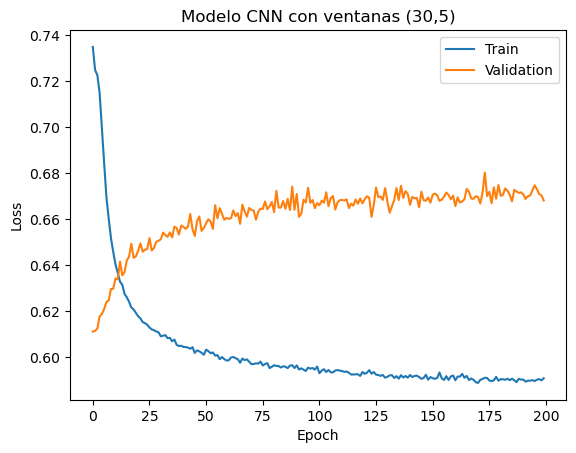

In [45]:
plt.plot(hist_CNN_30_5.history['loss'])
plt.plot(hist_CNN_30_5.history['val_loss'])
#plt.axhline(0.0055)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation', 'Regresión Lineal'])
plt.title('Modelo CNN con ventanas (30,5)')
plt.show()

In [47]:
# 1. El modelo predice en escala normalizada usando los datos de test
y_pred_cnn_scaled_train_30_5 = model_CNN_30_5.predict(train_data_30_5)
y_pred_cnn_scaled_val_30_5 = model_CNN_30_5.predict(val_data_30_5)
y_pred_cnn_scaled_test_30_5 = model_CNN_30_5.predict(test_data_30_5)

# 2. Deshacemos la normalización usando el scaler de la llave (10,5)
scaler_y_30_5 = dicc_scaler[(30,5)]
y_pred_cnn_real_train_30_5 = scaler_y_30_5.inverse_transform(y_pred_cnn_scaled_train_30_5)
y_pred_cnn_real_val_30_5 = scaler_y_30_5.inverse_transform(y_pred_cnn_scaled_val_30_5)
y_pred_cnn_real_test_30_5 = scaler_y_30_5.inverse_transform(y_pred_cnn_scaled_test_30_5)

# 3. Comparamos las predicciones reales contra los datos originales sin normalizar
mae_cnn_train_30_5 = mean_absolute_error(dicc_target_train_reg[(30,5)], y_pred_cnn_real_train_30_5)
mae_cnn_val_30_5 = mean_absolute_error(dicc_target_val[(30,5)], y_pred_cnn_real_val_30_5)
mae_cnn_test_30_5 = mean_absolute_error(dicc_target_test[(30,5)], y_pred_cnn_real_test_30_5)

# 4. Comparamos manzanas con manzanas
print()
print('=======   Resultados modelo CNN (30,5)   =======')
print()
print(f"MAE de la Regresión Lineal (train): {mae_reg_train[(30,5)]:.6f}")
print(f"MAE de la Red Neuronal (train):     {mae_cnn_train_30_5:.6f}")
print()
print(f"MAE de la Regresión Lineal (val): {mae_reg_val[(30,5)]:.6f}")
print(f"MAE de la Red Neuronal (val):     {mae_cnn_val_30_5:.6f}")
print()
print(f"MAE de la Regresión Lineal (test): {mae_reg_test[(30,5)]:.6f}")
print(f"MAE de la Red Neuronal (test):     {mae_cnn_test_30_5:.6f}")
print()

341/341 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step
114/114 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step

=======   Resultados modelo CNN (30,5)   =======

MAE de la Regresión Lineal (train): 0.005402
MAE de la Red Neuronal (train):     0.004252

MAE de la Regresión Lineal (val): 0.004852
MAE de la Red Neuronal (val):     0.005077

MAE de la Regresión Lineal (test): 0.005921
MAE de la Red Neuronal (test):     0.006214



##### 3.3.3.3. Modelo con 30 datos de salida

In [48]:
train_data_30_30, train_target_30_30 = dicc_data_train_norm[(30,30)], dicc_target_train_norm[(30,30)]
val_data_30_30, val_target_30_30 = dicc_data_val_norm[(30,30)], dicc_target_val_norm[(30,30)]
test_data_30_30, test_target_30_30 = dicc_data_test_norm[(30,30)], dicc_target_test_norm[(30,30)]

In [53]:
model_CNN_30_30 = Sequential()

# 1. Capa Convolucional
model_CNN_30_30.add(Convolution1D(filters=32, kernel_size=7, activation="relu", padding='same', input_shape=(train_data_30_30.shape[1], train_data_30_30.shape[2])))
model_CNN_30_30.add(MaxPooling1D())
model_CNN_30_30.add(Convolution1D(filters=32, kernel_size=3, activation="relu", padding='same', kernel_regularizer=regularizers.l2(0.005)))
model_CNN_30_30.add(MaxPooling1D())

# 2. Aplanamos la secuencia
model_CNN_30_30.add(Flatten())
model_CNN_30_30.add(Dropout(0.5))

# 3. Capa Densa de Salida
model_CNN_30_30.add(Dense(train_target_30_30.shape[1], activation='linear'))

# 4. COMPILACIÓN (BAJAMOS el learning rate a 0.0001)
model_CNN_30_30.compile(loss='mean_absolute_error', optimizer=Adam(learning_rate=0.001))

c:\Users\mateo\anaconda31\envs\trading\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [54]:
# NO escalamos y porque son retornos (valores pequeños) que el modelo debe aprender directamente
# Usar datos escalados de entrada pero targets sin escalar adicional
hist_CNN_30_30 = model_CNN_30_30.fit(train_data_30_30, train_target_30_30, validation_data=(val_data_30_30, val_target_30_30), epochs=200)

Epoch 1/200
341/341 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - loss: 0.8471 - val_loss: 0.6729
Epoch 2/200
341/341 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 0.7639 - val_loss: 0.6497
Epoch 3/200
341/341 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 0.7438 - val_loss: 0.6563
Epoch 4/200
341/341 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.6988 - val_loss: 0.6587
Epoch 5/200
341/341 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.6687 - val_loss: 0.6945
Epoch 6/200
341/341 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.6589 - val_loss: 0.6574
Epoch 7/200
341/341 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 0.6527 - val_loss: 0.6693
Epoch 8/200
341/341 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.6499 - val_loss: 0.6745
Epoch 9/200
341/341 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.6481 - val_loss: 0.6582
Epoch 10/200
341/341 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 0.6453 - val_loss: 0.6709
Epoch 11/200
341/341 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 0.6433 - val_loss: 0.6631
Epoch 12/200
341/341 ━━━━━━━━━━━━━━

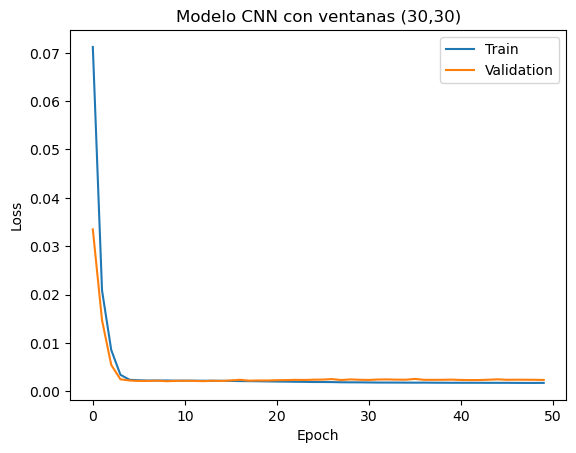

In [ ]:
plt.plot(hist_CNN_30_30.history['loss'])
plt.plot(hist_CNN_30_30.history['val_loss'])
#plt.axhline(0.0055)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation', 'Regresión Lineal'])
plt.title('Modelo CNN con ventanas (30,30)')
plt.show()

In [ ]:
# 1. El modelo predice en escala normalizada usando los datos de test
y_pred_cnn_scaled_train_30_30 = model_CNN_10_30.predict(train_data_30_30)
y_pred_cnn_scaled_val_30_30 = model_CNN_30_30.predict(val_data_30_30)
y_pred_cnn_scaled_test_30_30 = model_CNN_30_30.predict(test_data_30_30)

# 2. Deshacemos la normalización usando el scaler de la llave (10,5)
scaler_y_30_30 = dicc_scaler[(30,30)]
y_pred_cnn_real_train_30_30 = scaler_y_30_30.inverse_transform(y_pred_cnn_scaled_train_30_30)
y_pred_cnn_real_val_30_30 = scaler_y_30_30.inverse_transform(y_pred_cnn_scaled_val_30_30)
y_pred_cnn_real_test_30_30 = scaler_y_30_30.inverse_transform(y_pred_cnn_scaled_test_30_30)

# 3. Comparamos las predicciones reales contra los datos originales sin normalizar
mae_cnn_train_30_30 = mean_absolute_error(dicc_target_train_reg[(30,30)], y_pred_cnn_real_train_30_30)
mae_cnn_val_30_30 = mean_absolute_error(dicc_target_val[(30,30)], y_pred_cnn_real_val_30_30)
mae_cnn_test_30_30 = mean_absolute_error(dicc_target_test[(30,30)], y_pred_cnn_real_test_30_30)

# 4. Comparamos manzanas con manzanas
print()
print('=======   Resultados modelo CNN (30,30)   =======')
print()
print(f"MAE de la Regresión Lineal (train): {mae_reg_train[(30,30)]:.6f}")
print(f"MAE de la Red Neuronal (train):     {mae_cnn_train_30_30:.6f}")
print()
print(f"MAE de la Regresión Lineal (val): {mae_reg_val[(30,30)]:.6f}")
print(f"MAE de la Red Neuronal (val):     {mae_cnn_val_30_30:.6f}")
print()
print(f"MAE de la Regresión Lineal (test): {mae_reg_test[(30,30)]:.6f}")
print(f"MAE de la Red Neuronal (test):     {mae_cnn_test_30_30:.6f}")
print()

##### 3.3.3.4. Modelo con 90 datos de salida

In [ ]:
train_data_30_90, train_target_30_90 = dicc_data_train_norm[(30,90)], dicc_target_train_norm[(30,90)]
val_data_30_90, val_target_30_90 = dicc_data_val_norm[(30,90)], dicc_target_val_norm[(30,90)]
test_data_30_90, test_target_30_90 = dicc_data_test_norm[(30,90)], dicc_target_test_norm[(30,90)]

In [ ]:
model_CNN_30_90 = Sequential()

# 1. Capa Convolucional
model_CNN_30_90.add(Convolution1D(filters=32, kernel_size=3, activation="relu", padding='same', input_shape=(train_data_30_90.shape[1], train_data_30_90.shape[2])))
model_CNN_30_90.add(Convolution1D(filters=32, kernel_size=3, activation="relu", padding='same'))

# 2. Aplanamos la secuencia
model_CNN_30_90.add(Flatten())
model_CNN_30_90.add(Dropout(0.3))

# 3. Capa Densa de Salida
model_CNN_30_90.add(Dense(train_target_30_90.shape[1], activation='linear'))

# 4. COMPILACIÓN (BAJAMOS el learning rate a 0.0001)
model_CNN_30_90.compile(loss='mean_absolute_error', optimizer=Adam(learning_rate=0.001))

Model: "sequential_42"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_27 (Conv1D)              │ (None, 30, 32)         │         2,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_14 (MaxPooling1D) │ (None, 15, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_28 (Conv1D)              │ (None, 15, 23)         │           759 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_13     │ (None, 23)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,999 (11.71 KB)

 Trainable params: 2,999 (11.71 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# NO escalamos y porque son retornos (valores pequeños) que el modelo debe aprender directamente
# Usar datos escalados de entrada pero targets sin escalar adicional
hist_CNN_30_90 = model_CNN_30_90.fit(train_data_30_90, train_target_30_90, validation_data=(val_data_30_90, val_target_30_90), epochs=300)

Epoch 1/50
339/339 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - loss: 0.0722 - val_loss: 0.0331
Epoch 2/50
339/339 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0204 - val_loss: 0.0145
Epoch 3/50
339/339 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0083 - val_loss: 0.0050
Epoch 4/50
339/339 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0027 - val_loss: 0.0016
Epoch 5/50
339/339 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0014 - val_loss: 0.0013
Epoch 6/50
339/339 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0013 - val_loss: 0.0013
Epoch 7/50
339/339 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0013 - val_loss: 0.0013
Epoch 8/50
339/339 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0013 - val_loss: 0.0013
Epoch 9/50
339/339 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0013 - val_loss: 0.0014
Epoch 10/50
339/339 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0013 - val_loss: 0.0012
Epoch 11/50
339/339 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0013 - val_loss: 0.0013
Epoch 12/50
339/339 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step

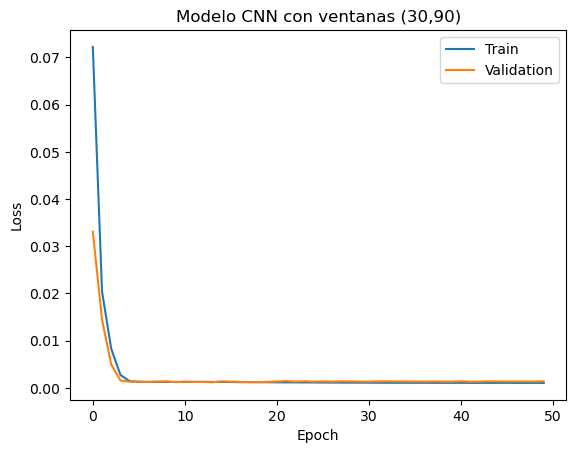

In [ ]:
plt.plot(hist_CNN_30_90.history['loss'])
plt.plot(hist_CNN_30_90.history['val_loss'])
#plt.axhline(0.0055)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation', 'Regresión Lineal'])
plt.title('Modelo CNN con ventanas (30,90)')
plt.show()

#### 3.3.4 Modelos con 90 datos de entrada

##### 3.3.4.1. Modelo con 1 dato de salida

In [ ]:
train_data_90_1, train_target_90_1 = dicc_data_train_norm[(90,1)], dicc_target_train_norm[(90,1)]
val_data_90_1, val_target_90_1 = dicc_data_val_norm[(90,1)], dicc_target_val_norm[(90,1)]
test_data_90_1, test_target_90_1 = dicc_data_test_norm[(90,1)], dicc_target_test_norm[(90,1)]

In [ ]:
model_CNN_90_1 = Sequential()

# 1. Capa Convolucional
model_CNN_90_1.add(Convolution1D(filters=32, kernel_size=3, activation="relu", padding='same', input_shape=(train_data_90_1.shape[1], train_data_90_1.shape[2])))
model_CNN_90_1.add(Convolution1D(filters=32, kernel_size=3, activation="relu", padding='same'))

# 2. Aplanamos la secuencia
model_CNN_90_1.add(Flatten())
model_CNN_90_1.add(Dropout(0.3))

# 3. Capa Densa de Salida
model_CNN_90_1.add(Dense(train_target_90_1.shape[1], activation='linear'))

# 4. COMPILACIÓN (BAJAMOS el learning rate a 0.0001)
model_CNN_90_1.compile(loss='mean_absolute_error', optimizer=Adam(learning_rate=0.001))

Model: "sequential_43"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_29 (Conv1D)              │ (None, 90, 32)         │         2,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_15 (MaxPooling1D) │ (None, 45, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_30 (Conv1D)              │ (None, 45, 23)         │           759 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_14     │ (None, 23)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,999 (11.71 KB)

 Trainable params: 2,999 (11.71 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# NO escalamos y porque son retornos (valores pequeños) que el modelo debe aprender directamente
# Usar datos escalados de entrada pero targets sin escalar adicional
hist_CNN_90_1 = model_CNN_90_1.fit(train_data_90_1, train_target_90_1, validation_data=(val_data_90_1, val_target_90_1), epochs=300)

Epoch 1/50
340/340 ━━━━━━━━━━━━━━━━━━━━ 9s 15ms/step - loss: 0.0724 - val_loss: 0.0343
Epoch 2/50
340/340 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0204 - val_loss: 0.0237
Epoch 3/50
340/340 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0162 - val_loss: 0.0193
Epoch 4/50
340/340 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0145 - val_loss: 0.0161
Epoch 5/50
340/340 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0136 - val_loss: 0.0148
Epoch 6/50
340/340 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0131 - val_loss: 0.0135
Epoch 7/50
340/340 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0128 - val_loss: 0.0127
Epoch 8/50
340/340 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0126 - val_loss: 0.0120
Epoch 9/50
340/340 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0124 - val_loss: 0.0114
Epoch 10/50
340/340 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0124 - val_loss: 0.0110
Epoch 11/50
340/340 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0123 - val_loss: 0.0109
Epoch 12/50
340/340 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/ste

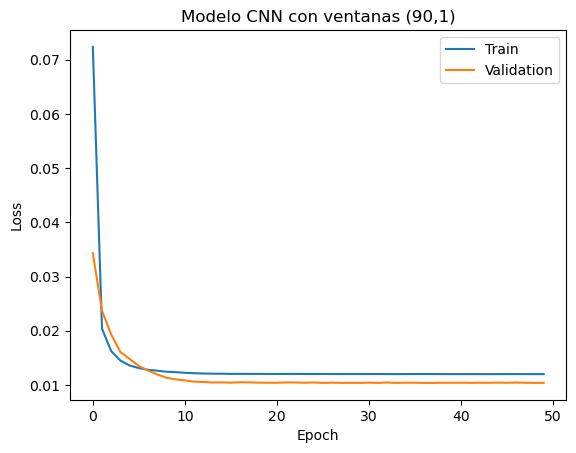

In [ ]:
plt.plot(hist_CNN_90_1.history['loss'])
plt.plot(hist_CNN_90_1.history['val_loss'])
#plt.axhline(0.0055)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation', 'Regresión Lineal'])
plt.title('Modelo CNN con ventanas (90,1)')
plt.show()

##### 3.3.4.2. Modelo con 5 datos de salida

In [ ]:
train_data_90_5, train_target_90_5 = dicc_data_train_norm[(90,5)], dicc_target_train_norm[(90,5)]
val_data_90_5, val_target_90_5 = dicc_data_val_norm[(90,5)], dicc_target_val_norm[(90,5)]
test_data_90_5, test_target_90_5 = dicc_data_test_norm[(90,5)], dicc_target_test_norm[(90,5)]

In [ ]:
model_CNN_90_5 = Sequential()

# 1. Capa Convolucional
model_CNN_90_5.add(Convolution1D(filters=32, kernel_size=3, activation="relu", padding='same', input_shape=(train_data_90_5.shape[1], train_data_90_5.shape[2])))
model_CNN_90_5.add(Convolution1D(filters=32, kernel_size=3, activation="relu", padding='same'))

# 2. Aplanamos la secuencia
model_CNN_90_5.add(Flatten())
model_CNN_90_5.add(Dropout(0.3))

# 3. Capa Densa de Salida
model_CNN_90_5.add(Dense(train_target_90_5.shape[1], activation='linear'))

# 4. COMPILACIÓN (BAJAMOS el learning rate a 0.0001)
model_CNN_90_5.compile(loss='mean_absolute_error', optimizer=Adam(learning_rate=0.001))

Model: "sequential_44"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_31 (Conv1D)              │ (None, 90, 32)         │         2,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_16 (MaxPooling1D) │ (None, 45, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_32 (Conv1D)              │ (None, 45, 23)         │           759 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_15     │ (None, 23)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,999 (11.71 KB)

 Trainable params: 2,999 (11.71 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# NO escalamos y porque son retornos (valores pequeños) que el modelo debe aprender directamente
# Usar datos escalados de entrada pero targets sin escalar adicional
hist_CNN_90_5 = model_CNN_90_5.fit(train_data_90_5, train_target_90_5, validation_data=(val_data_90_5, val_target_90_5), epochs=300)

Epoch 1/50
340/340 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - loss: 0.0508 - val_loss: 0.0300
Epoch 2/50
340/340 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0167 - val_loss: 0.0207
Epoch 3/50
340/340 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0114 - val_loss: 0.0151
Epoch 4/50
340/340 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0088 - val_loss: 0.0109
Epoch 5/50
340/340 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0075 - val_loss: 0.0086
Epoch 6/50
340/340 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0067 - val_loss: 0.0072
Epoch 7/50
340/340 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0062 - val_loss: 0.0064
Epoch 8/50
340/340 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0059 - val_loss: 0.0057
Epoch 9/50
340/340 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0058 - val_loss: 0.0054
Epoch 10/50
340/340 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 0.0057 - val_loss: 0.0052
Epoch 11/50
340/340 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 0.0057 - val_loss: 0.0050
Epoch 12/50
340/340 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/

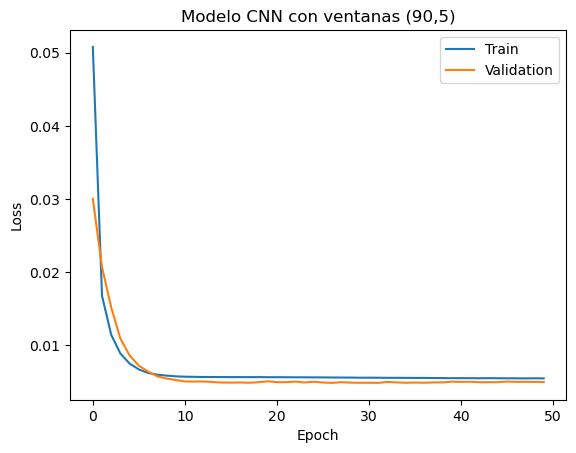

In [ ]:
plt.plot(hist_CNN_90_5.history['loss'])
plt.plot(hist_CNN_90_5.history['val_loss'])
#plt.axhline(0.0055)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation', 'Regresión Lineal'])
plt.title('Modelo CNN con ventanas (90,5)')
plt.show()

##### 3.3.4.3. Modelo con 30 datos de salida

In [ ]:
train_data_90_30, train_target_90_30 = dicc_data_train_norm[(90,30)], dicc_target_train_norm[(90,30)]
val_data_90_30, val_target_90_30 = dicc_data_val_norm[(90,30)], dicc_target_val_norm[(90,30)]
test_data_90_30, test_target_90_30 = dicc_data_test_norm[(90,30)], dicc_target_test_norm[(90,30)]

In [ ]:
model_CNN_90_30 = Sequential()

# 1. Capa Convolucional
model_CNN_90_30.add(Convolution1D(filters=32, kernel_size=3, activation="relu", padding='same', input_shape=(train_data_90_30.shape[1], train_data_90_30.shape[2])))
model_CNN_90_30.add(Convolution1D(filters=32, kernel_size=3, activation="relu", padding='same'))

# 2. Aplanamos la secuencia
model_CNN_90_30.add(Flatten())
model_CNN_90_30.add(Dropout(0.3))

# 3. Capa Densa de Salida
model_CNN_90_30.add(Dense(train_target_90_30.shape[1], activation='linear'))

# 4. COMPILACIÓN (BAJAMOS el learning rate a 0.0001)
model_CNN_90_30.compile(loss='mean_absolute_error', optimizer=Adam(learning_rate=0.001))

Model: "sequential_45"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_33 (Conv1D)              │ (None, 90, 32)         │         2,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_17 (MaxPooling1D) │ (None, 45, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_34 (Conv1D)              │ (None, 45, 23)         │           759 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_16     │ (None, 23)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,999 (11.71 KB)

 Trainable params: 2,999 (11.71 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# NO escalamos y porque son retornos (valores pequeños) que el modelo debe aprender directamente
# Usar datos escalados de entrada pero targets sin escalar adicional
hist_CNN_90_30 = model_CNN_90_30.fit(train_data_90_30, train_target_90_30, validation_data=(val_data_90_30, val_target_90_30), epochs=300)

Epoch 1/50
339/339 ━━━━━━━━━━━━━━━━━━━━ 30s 10ms/step - loss: 0.0605 - val_loss: 0.0303
Epoch 2/50
339/339 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0151 - val_loss: 0.0192
Epoch 3/50
339/339 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0090 - val_loss: 0.0122
Epoch 4/50
339/339 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0059 - val_loss: 0.0084
Epoch 5/50
339/339 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0041 - val_loss: 0.0054
Epoch 6/50
339/339 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.0031 - val_loss: 0.0039
Epoch 7/50
339/339 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.0025 - val_loss: 0.0030
Epoch 8/50
339/339 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0023 - val_loss: 0.0025
Epoch 9/50
339/339 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0022 - val_loss: 0.0024
Epoch 10/50
339/339 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0021 - val_loss: 0.0025
Epoch 11/50
339/339 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0021 - val_loss: 0.0023
Epoch 12/50
339/339 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/st

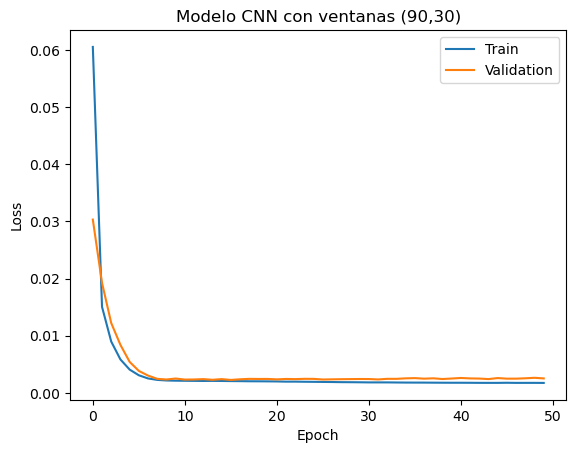

In [ ]:
plt.plot(hist_CNN_90_30.history['loss'])
plt.plot(hist_CNN_90_30.history['val_loss'])
#plt.axhline(0.0055)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation', 'Regresión Lineal'])
plt.title('Modelo CNN con ventanas (90,30)')
plt.show()

##### 3.3.4.4. Modelo con 90 datos de salida

In [ ]:
train_data_90_90, train_target_90_90 = dicc_data_train_norm[(90,90)], dicc_target_train_norm[(90,90)]
val_data_90_90, val_target_90_90 = dicc_data_val_norm[(90,90)], dicc_target_val_norm[(90,90)]
test_data_90_90, test_target_90_90 = dicc_data_test_norm[(90,90)], dicc_target_test_norm[(90,90)]

In [ ]:
model_CNN_90_90 = Sequential()

# 1. Capa Convolucional
model_CNN_90_90.add(Convolution1D(filters=32, kernel_size=3, activation="relu", padding='same', input_shape=(train_data_90_30.shape[1], train_data_90_30.shape[2])))
model_CNN_90_90.add(Convolution1D(filters=32, kernel_size=3, activation="relu", padding='same'))

# 2. Aplanamos la secuencia
model_CNN_90_90.add(Flatten())
model_CNN_90_90.add(Dropout(0.3))

# 3. Capa Densa de Salida
model_CNN_90_90.add(Dense(train_target_90_30.shape[1], activation='linear'))

# 4. COMPILACIÓN (BAJAMOS el learning rate a 0.0001)
model_CNN_90_90.compile(loss='mean_absolute_error', optimizer=Adam(learning_rate=0.001))

In [ ]:
# NO escalamos y porque son retornos (valores pequeños) que el modelo debe aprender directamente
# Usar datos escalados de entrada pero targets sin escalar adicional
hist_CNN_90_90 = model_CNN_90_90.fit(train_data_90_90, train_target_90_90, validation_data=(val_data_90_90, val_target_90_90), epochs=300)

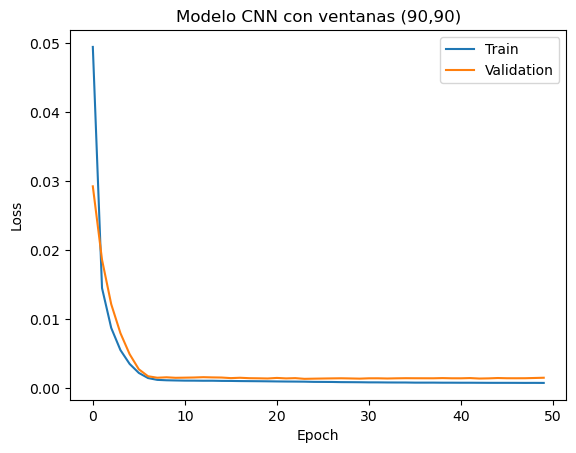

In [ ]:
plt.plot(hist_CNN_90_90.history['loss'])
plt.plot(hist_CNN_90_90.history['val_loss'])
#plt.axhline(0.0055)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation', 'Regresión Lineal'])
plt.title('Modelo CNN con ventanas (90,90)')
plt.show()